<a href="https://colab.research.google.com/github/RiaKodo/testpsych/blob/main/NAPLS%202%20UC%20vs%20CHR%20and%20CHR%20t/nt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download the file from GitHub

In [5]:
import requests

url = 'https://raw.githubusercontent.com/RiaKodo/testpsych/main/NAPLS2%20complement%20full%20UC%20and%20cHR.xlsx'
file_name = 'NAPLS2_complement_full_UC_and_cHR.xlsx'

response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors

with open(file_name, 'wb') as f:
    f.write(response.content)

print(f"File '{file_name}' downloaded successfully.")

File 'NAPLS2_complement_full_UC_and_cHR.xlsx' downloaded successfully.


### Load the Excel file into a pandas DataFrame

In [4]:
import pandas as pd

df = pd.read_excel(file_name)
display(df.head())

,TCC,C3a,Bb,C5a,C4a,iC3b,C4d,alt_id,antipsychotics,antidepressants,tobaccoUse,tobaccoFreq,marijuanaUse,marijuanaFreq,TYPE,Transition,Sex,Age,Race
0,282.107348,214.003887,1.349521,10.133230,463.043940,18.745095,5.025043,05-0156,0,1,1.0,0.0,1.0,0.0,CHR,1.0,female,23.0,European
1,139.697195,42.621423,1.122822,2.594703,415.693723,8.660668,2.862299,07-0169,0,1,1.0,0.0,1.0,0.0,CHR,1.0,female,21.0,European
2,188.973427,82.778440,1.290280,1.710782,1128.400190,27.189932,2.717999,04-0149,1,1,1.0,0.0,1.0,0.0,CHR,1.0,female,15.0,West or Central Asian and Middle Eastern
3,268.506296,92.846676,0.979594,13.461897,411.698750,20.698711,8.141078,07-0133,0,1,1.0,0.0,1.0,0.0,CHR,1.0,female,14.0,European
4,164.501167,195.670905,1.280375,14.340872,768.624706,33.286713,4.845983,02-0091,1,1,1.0,0.0,1.0,0.0,CHR,1.0,female,13.0,South Asian


In [33]:
import statsmodels.formula.api as smf

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Comparing 'Transition' vs 'No Transition' within the 'CHR' group, accounting for Sex, Age, and Race:\n")

for col in columns_to_analyze:
    # Define the model formula. C() treats a variable as categorical.
    formula = f"{col} ~ C(Transition) + C(Sex) + Age + C(Race)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_only[[col, 'Transition', 'Sex', 'Age', 'Race']].dropna()

    print(f"--- {col} ---")
    if not model_df.empty:
        # Debugging: Check the unique values and counts of 'Transition' in model_df
        transition_counts = model_df['Transition'].value_counts()
        print(f"  Transition value counts in model_df: {transition_counts.to_dict()}")

        if model_df['Transition'].nunique() > 1:
            try:
                model = smf.ols(formula=formula, data=model_df).fit()
                # Extract the p-value for the 'C(Transition)[T.1]' coefficient
                # 'T.1' indicates the '1' level of the Transition variable, comparing to the reference level (likely '0')
                # Debugging: Print all p-value keys to find the exact name
                # print(f"  All p-value keys: {list(model.pvalues.index)}")

                if 'C(Transition)[T.1.0]' in model.pvalues.index:
                    p_value = model.pvalues['C(Transition)[T.1.0]']
                    print(f"  P-value for Transition (accounting for Sex, Age, Race): {p_value:.3f}")
                    if p_value < 0.05:
                        print("  Conclusion: Significant difference in Transition status after accounting for covariates (p < 0.05)\n")
                    else:
                        print("  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)\n")
                else:
                    print("  Transition coefficient not found in model results (possibly due to collinearity or one group having no variation after covariate adjustment).")
                    print("  All model p-values:")
                    print(model.pvalues) # Print all p-values for debugging
                    print("\n")
            except Exception as e:
                print(f"  Could not fit model for {col}: {e}\n")
        else:
            print(f"  Not enough variability in 'Transition' to fit model for {col} after dropping NaNs. Only one unique value or less after filtering.\n")
    else:
        print(f"  Not enough data to fit model for {col} after dropping NaNs. model_df is empty.\n")


Comparing 'Transition' vs 'No Transition' within the 'CHR' group, accounting for Sex, Age, and Race:

--- TCC ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.204
  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)

--- C3a ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.246
  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)

--- Bb ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.626
  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)

--- C5a ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.151
  Conclusion: No significant difference i

### Statistical Analysis: Comparing Transition vs. No Transition within CHR, accounting for Sex, Age, and Race, with FDR Correction

In [38]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction), accounting for Sex, Age, and Race:\n")

# Collect p-values for FDR correction
original_p_values = []
columns_for_fdr = []

for col in columns_to_analyze:
    # Define the model formula.
    formula = f"{col} ~ C(Transition) + C(Sex) + Age + C(Race)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_only[[col, 'Transition', 'Sex', 'Age', 'Race']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                original_p_values.append(p_value)
                columns_for_fdr.append(col)
            # else: We'll skip columns where the coefficient wasn't found, as its effect can't be assessed.
        except Exception:
            # Skip if model fitting fails
            pass

# Apply FDR correction
if original_p_values:
    reject, p_corrected, _, _ = multipletests(original_p_values, alpha=0.05, method='fdr_bh')

    # Display results
    print("--- FDR Corrected P-values for Transition (in CHR group) ---")
    results = pd.DataFrame({
        'Column': columns_for_fdr,
        'Original P-value': original_p_values,
        'FDR-corrected P-value': p_corrected,
        'Significant (FDR < 0.05)': reject
    })
    results['Original P-value'] = results['Original P-value'].map(lambda x: f"{x:.3f}")
    results['FDR-corrected P-value'] = results['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results)

    # Summarize overall conclusion
    if any(reject):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status after accounting for covariates.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for covariates (FDR >= 0.05).")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers.")

Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction), accounting for Sex, Age, and Race:

--- FDR Corrected P-values for Transition (in CHR group) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.204,0.430,False
1,C3a,0.246,0.430,False
2,Bb,0.626,0.730,False
3,C5a,0.151,0.430,False
4,C4a,0.981,0.981,False
5,iC3b,0.123,0.430,False
6,C4d,0.347,0.485,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for covariates (FDR >= 0.05).


In [37]:
# Execute the FDR correction for ANCOVA results
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction), accounting for Sex, Age, and Race:\n")

# Collect p-values for FDR correction
original_p_values = []
columns_for_fdr = []

for col in columns_to_analyze:
    # Define the model formula.
    formula = f"{col} ~ C(Transition) + C(Sex) + Age + C(Race)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_only[[col, 'Transition', 'Sex', 'Age', 'Race']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                original_p_values.append(p_value)
                columns_for_fdr.append(col)
            # else: We'll skip columns where the coefficient wasn't found, as its effect can't be assessed.
        except Exception:
            # Skip if model fitting fails
            pass

# Apply FDR correction
if original_p_values:
    reject, p_corrected, _, _ = multipletests(original_p_values, alpha=0.05, method='fdr_bh')

    # Display results
    print("--- FDR Corrected P-values for Transition (in CHR group) ---")
    results = pd.DataFrame({
        'Column': columns_for_fdr,
        'Original P-value': original_p_values,
        'FDR-corrected P-value': p_corrected,
        'Significant (FDR < 0.05)': reject
    })
    results['Original P-value'] = results['Original P-value'].map(lambda x: f"{x:.3f}")
    results['FDR-corrected P-value'] = results['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results)

    # Summarize overall conclusion
    if any(reject):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status after accounting for covariates.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for covariates (FDR >= 0.05).")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers.")


Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction), accounting for Sex, Age, and Race:

--- FDR Corrected P-values for Transition (in CHR group) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.204,0.430,False
1,C3a,0.246,0.430,False
2,Bb,0.626,0.730,False
3,C5a,0.151,0.430,False
4,C4a,0.981,0.981,False
5,iC3b,0.123,0.430,False
6,C4d,0.347,0.485,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for covariates (FDR >= 0.05).


### Statistical Analysis: Comparing Transition vs. No Transition within CHR, accounting for Sex, Age, and Race, with FDR Correction

In [36]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction), accounting for Sex, Age, and Race:\n")

# Collect p-values for FDR correction
original_p_values = []
columns_for_fdr = []

for col in columns_to_analyze:
    # Define the model formula.
    formula = f"{col} ~ C(Transition) + C(Sex) + Age + C(Race)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_only[[col, 'Transition', 'Sex', 'Age', 'Race']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                original_p_values.append(p_value)
                columns_for_fdr.append(col)
            # else: We'll skip columns where the coefficient wasn't found, as its effect can't be assessed.
        except Exception:
            # Skip if model fitting fails
            pass

# Apply FDR correction
if original_p_values:
    reject, p_corrected, _, _ = multipletests(original_p_values, alpha=0.05, method='fdr_bh')

    # Display results
    print("--- FDR Corrected P-values for Transition (in CHR group) ---")
    results = pd.DataFrame({
        'Column': columns_for_fdr,
        'Original P-value': original_p_values,
        'FDR-corrected P-value': p_corrected,
        'Significant (FDR < 0.05)': reject
    })
    results['Original P-value'] = results['Original P-value'].map(lambda x: f"{x:.3f}")
    results['FDR-corrected P-value'] = results['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results)

    # Summarize overall conclusion
    if any(reject):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status after accounting for covariates.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for covariates (FDR >= 0.05).")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers.")

Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction), accounting for Sex, Age, and Race:

--- FDR Corrected P-values for Transition (in CHR group) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.204,0.430,False
1,C3a,0.246,0.430,False
2,Bb,0.626,0.730,False
3,C5a,0.151,0.430,False
4,C4a,0.981,0.981,False
5,iC3b,0.123,0.430,False
6,C4d,0.347,0.485,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for covariates (FDR >= 0.05).


### Visualizing Differences within CHR group: Transition vs. No Transition (with FDR-corrected ANCOVA p-values)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR' group (annotated with FDR-corrected ANCOVA p-values)...


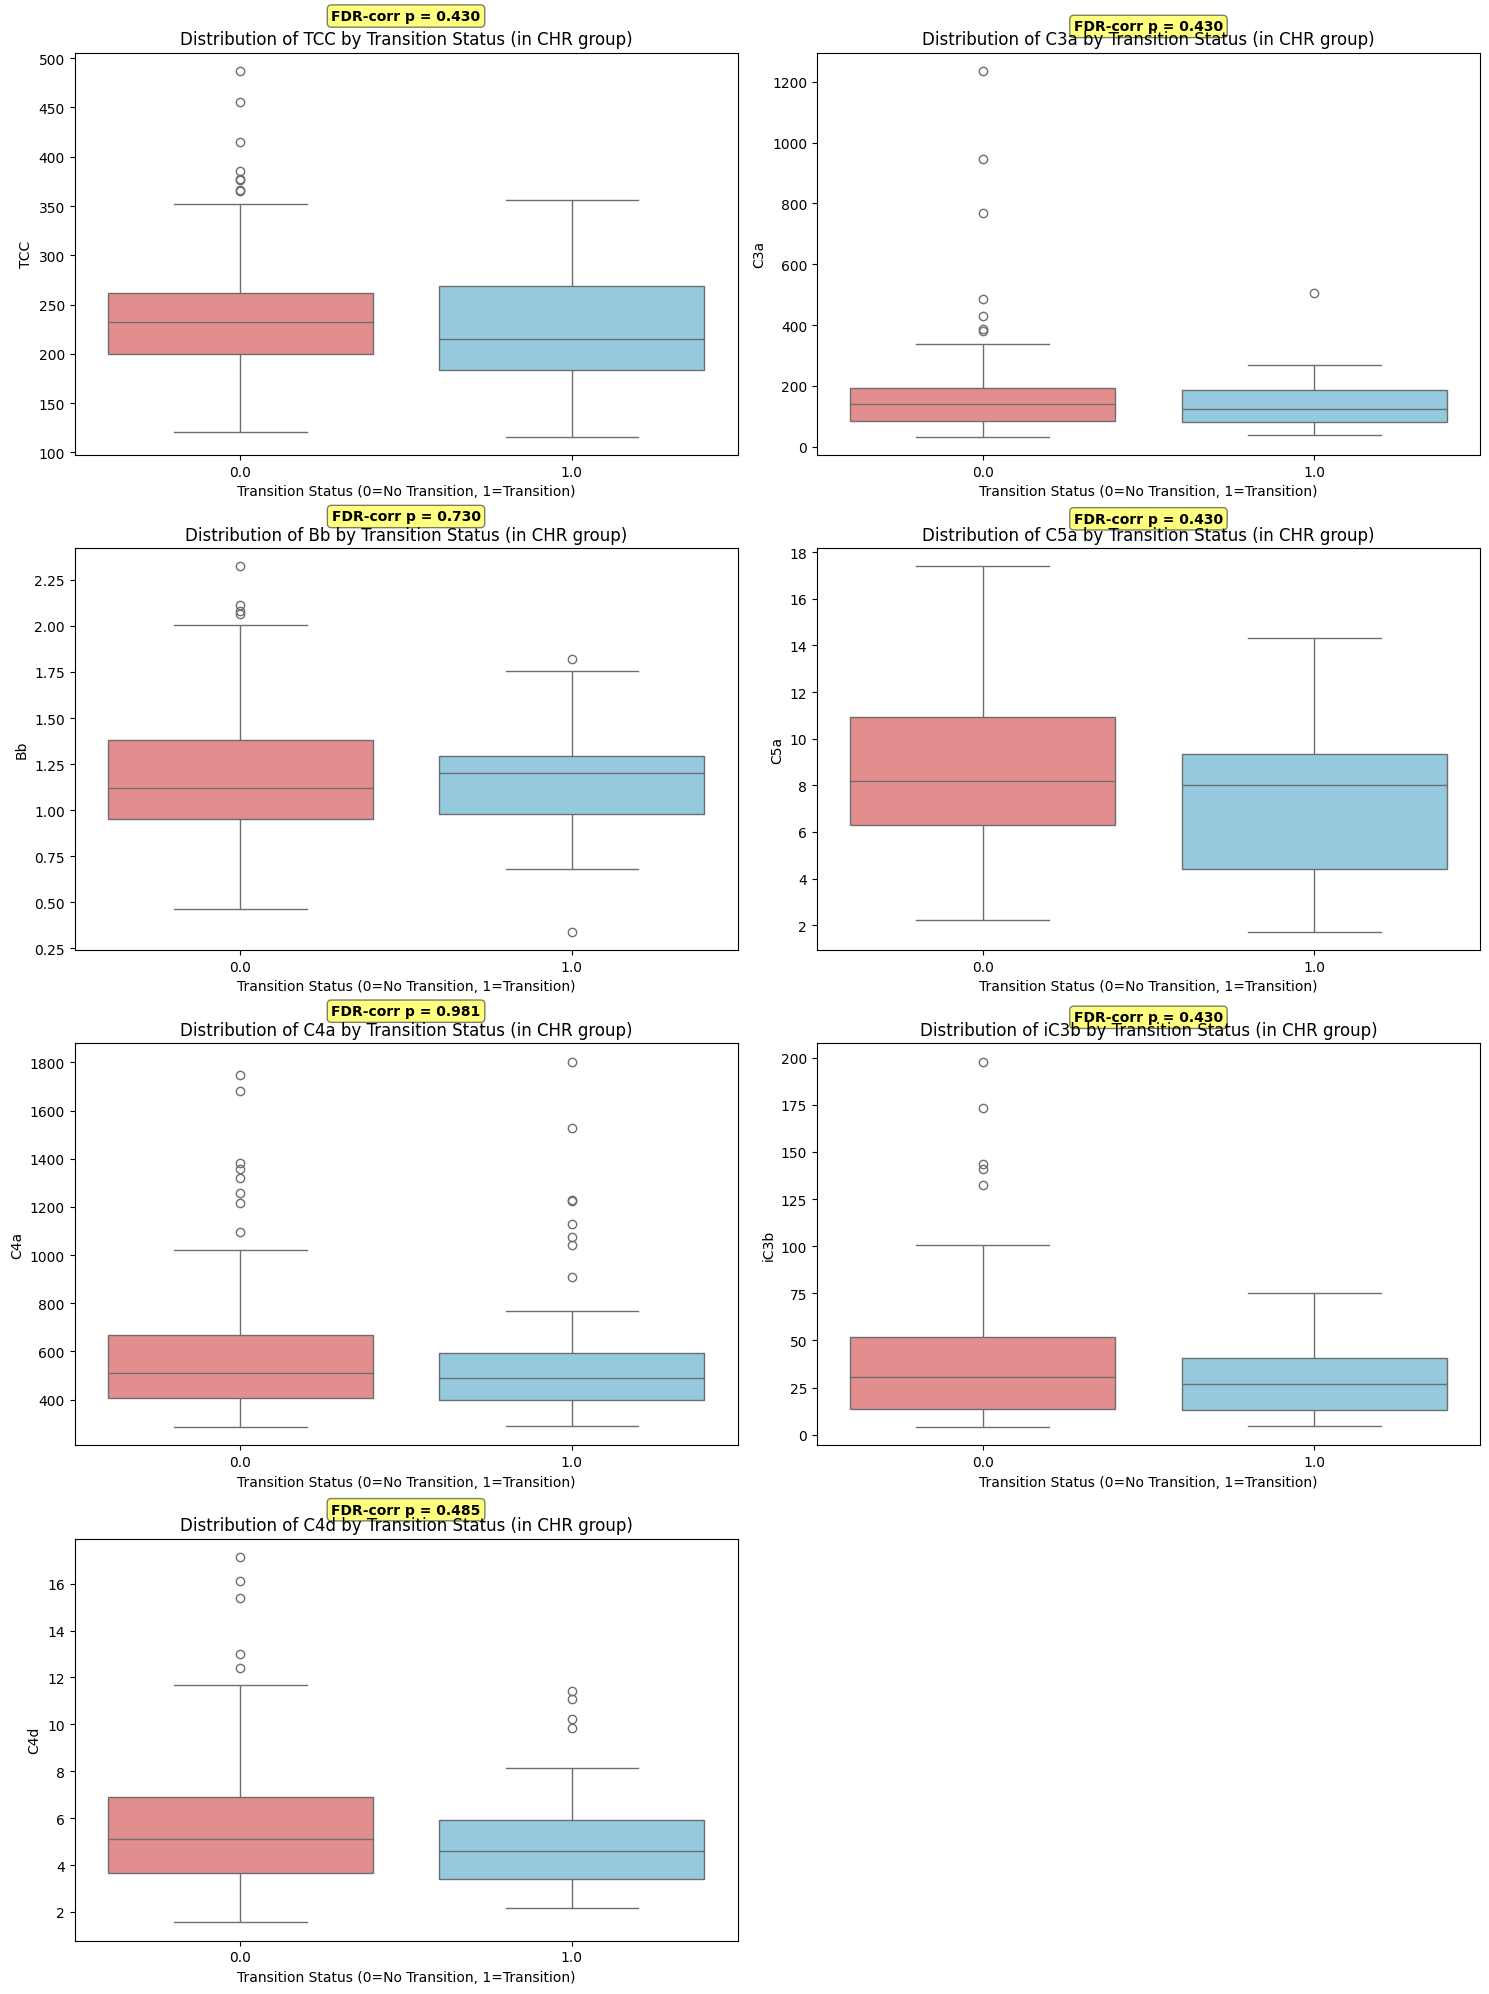

In [40]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for visualization and analysis
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

# Prepare to collect p-values for FDR correction (re-running the logic for clarity and self-containment)
original_p_values_ancova = []
columns_for_fdr_ancova = []

for col in columns_to_visualize:
    formula = f"{col} ~ C(Transition) + C(Sex) + Age + C(Race)"
    model_df = df_chr_only[[col, 'Transition', 'Sex', 'Age', 'Race']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                original_p_values_ancova.append(p_value)
                columns_for_fdr_ancova.append(col)
        except Exception:
            pass

p_corrected_dict_ancova = {}
if original_p_values_ancova:
    _, p_corrected_ancova, _, _ = multipletests(original_p_values_ancova, alpha=0.05, method='fdr_bh')
    p_corrected_dict_ancova = dict(zip(columns_for_fdr_ancova, p_corrected_ancova))


# Calculate number of rows and columns for subplots
num_cols = 2 # We want 2 columns for the plots
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(15, 5 * num_rows)) # Adjust figure size for multiple plots

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR' group (annotated with FDR-corrected ANCOVA p-values)...")

# Create box plots for each column comparing Transition and No Transition within CHR
for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1) # Position the subplot
    sns.boxplot(x='Transition', y=col, data=df_chr_only, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (in CHR group)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_ancova:
        p_value_fdr = p_corrected_dict_ancova[col]

        max_val = df_chr_only[col].max() * 1.1 # Get max value for current column and add some buffer
        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data)
        max_val = df_chr_only[col].max() * 1.1 if not df_chr_only[col].empty else 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Statistical Analysis: Comparing Transition vs. No Transition within CHR, broken down by Sex (without covariates, with FDR Correction)

In [41]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

# Create sex-based subgroups within CHR
df_chr_male = df_chr_only[df_chr_only['Sex'] == 'male'].copy()
df_chr_female = df_chr_only[df_chr_only['Sex'] == 'female'].copy()

print("Comparing 'Transition' vs 'No Transition' within CHR male subgroup (with FDR correction):")

# Collect p-values for FDR correction for male subgroup
p_values_male = []
columns_for_fdr_male = []

for col in columns_to_analyze:
    transition_values = df_chr_male[df_chr_male['Transition'] == 1][col].dropna()
    no_transition_values = df_chr_male[df_chr_male['Transition'] == 0][col].dropna()

    if len(transition_values) > 1 and len(no_transition_values) > 1:
        t_stat, p_value = stats.ttest_ind(transition_values, no_transition_values, equal_var=False) # Welch's t-test
        p_values_male.append(p_value)
        columns_for_fdr_male.append(col)

# Apply FDR correction for male subgroup
if p_values_male:
    reject_male, p_corrected_male, _, _ = multipletests(p_values_male, alpha=0.05, method='fdr_bh')
    print("--- FDR Corrected P-values for Transition (CHR Male Group) ---")
    results_male = pd.DataFrame({
        'Column': columns_for_fdr_male,
        'Original P-value': p_values_male,
        'FDR-corrected P-value': p_corrected_male,
        'Significant (FDR < 0.05)': reject_male
    })
    results_male['Original P-value'] = results_male['Original P-value'].map(lambda x: f"{x:.3f}")
    results_male['FDR-corrected P-value'] = results_male['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results_male)
    if any(reject_male):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status for CHR males.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR males (FDR >= 0.05).\n")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers for CHR males.\n")

print("Comparing 'Transition' vs 'No Transition' within CHR female subgroup (with FDR correction):")

# Collect p-values for FDR correction for female subgroup
p_values_female = []
columns_for_fdr_female = []

for col in columns_to_analyze:
    transition_values = df_chr_female[df_chr_female['Transition'] == 1][col].dropna()
    no_transition_values = df_chr_female[df_chr_female['Transition'] == 0][col].dropna()

    if len(transition_values) > 1 and len(no_transition_values) > 1:
        t_stat, p_value = stats.ttest_ind(transition_values, no_transition_values, equal_var=False) # Welch's t-test
        p_values_female.append(p_value)
        columns_for_fdr_female.append(col)

# Apply FDR correction for female subgroup
if p_values_female:
    reject_female, p_corrected_female, _, _ = multipletests(p_values_female, alpha=0.05, method='fdr_bh')
    print("--- FDR Corrected P-values for Transition (CHR Female Group) ---")
    results_female = pd.DataFrame({
        'Column': columns_for_fdr_female,
        'Original P-value': p_values_female,
        'FDR-corrected P-value': p_corrected_female,
        'Significant (FDR < 0.05)': reject_female
    })
    results_female['Original P-value'] = results_female['Original P-value'].map(lambda x: f"{x:.3f}")
    results_female['FDR-corrected P-value'] = results_female['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results_female)
    if any(reject_female):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status for CHR females.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR females (FDR >= 0.05).\n")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers for CHR females.\n")


Comparing 'Transition' vs 'No Transition' within CHR male subgroup (with FDR correction):
--- FDR Corrected P-values for Transition (CHR Male Group) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.140,0.196,False
1,C3a,0.136,0.196,False
2,Bb,0.909,0.909,False
3,C5a,0.088,0.196,False
4,C4a,0.469,0.547,False
5,iC3b,0.009,0.065,False
6,C4d,0.021,0.075,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR males (FDR >= 0.05).

Comparing 'Transition' vs 'No Transition' within CHR female subgroup (with FDR correction):
--- FDR Corrected P-values for Transition (CHR Female Group) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.492,0.767,False
1,C3a,0.271,0.756,False
2,Bb,0.324,0.756,False
3,C5a,0.548,0.767,False
4,C4a,0.218,0.756,False
5,iC3b,0.752,0.861,False
6,C4d,0.861,0.861,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR females (FDR >= 0.05).



### Statistical Analysis: Comparing Transition vs. No Transition within CHR Male Subgroup (accounting for Sex, Age, Race, tobaccoUse, and marijuanaUse, with FDR Correction)

In [42]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

# Create male subgroup within CHR
df_chr_male = df_chr_only[df_chr_only['Sex'] == 'male'].copy()

print("Comparing 'Transition' vs 'No Transition' within CHR male subgroup (with FDR correction, accounting for Age, Race, tobaccoUse, and marijuanaUse):\n")

# Collect p-values for FDR correction for male subgroup
p_values_male_ancova_cov = []
columns_for_fdr_male_ancova_cov = []

for col in columns_to_analyze:
    # Define the model formula with new covariates. C() treats a variable as categorical.
    formula = f"{col} ~ C(Transition) + Age + C(Race) + C(tobaccoUse) + C(marijuanaUse)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_male[[col, 'Transition', 'Age', 'Race', 'tobaccoUse', 'marijuanaUse']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                p_values_male_ancova_cov.append(p_value)
                columns_for_fdr_male_ancova_cov.append(col)
        except Exception as e:
            print(f"  Could not fit model for {col} in male subgroup: {e}\n")

# Apply FDR correction for male subgroup ANCOVA
if p_values_male_ancova_cov:
    reject_male_ancova_cov, p_corrected_male_ancova_cov, _, _ = multipletests(p_values_male_ancova_cov, alpha=0.05, method='fdr_bh')
    print("--- FDR Corrected P-values for Transition (CHR Male Group, with covariates) ---")
    results_male_ancova_cov = pd.DataFrame({
        'Column': columns_for_fdr_male_ancova_cov,
        'Original P-value': p_values_male_ancova_cov,
        'FDR-corrected P-value': p_corrected_male_ancova_cov,
        'Significant (FDR < 0.05)': reject_male_ancova_cov
    })
    results_male_ancova_cov['Original P-value'] = results_male_ancova_cov['Original P-value'].map(lambda x: f"{x:.3f}")
    results_male_ancova_cov['FDR-corrected P-value'] = results_male_ancova_cov['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results_male_ancova_cov)
    if any(reject_male_ancova_cov):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status for CHR males (with covariates).")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR males (with covariates, FDR >= 0.05).\n")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers for CHR males (with covariates).\n")

Comparing 'Transition' vs 'No Transition' within CHR male subgroup (with FDR correction, accounting for Age, Race, tobaccoUse, and marijuanaUse):

--- FDR Corrected P-values for Transition (CHR Male Group, with covariates) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.095,0.165,False
1,C3a,0.315,0.440,False
2,Bb,0.935,0.935,False
3,C5a,0.076,0.165,False
4,C4a,0.500,0.583,False
5,iC3b,0.050,0.165,False
6,C4d,0.074,0.165,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR males (with covariates, FDR >= 0.05).



### Statistical Analysis: Comparing Transition vs. No Transition within CHR Female Subgroup (accounting for Sex, Age, Race, tobaccoUse, and marijuanaUse, with FDR Correction)

In [43]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

# Create female subgroup within CHR
df_chr_female = df_chr_only[df_chr_only['Sex'] == 'female'].copy()

print("Comparing 'Transition' vs 'No Transition' within CHR female subgroup (with FDR correction, accounting for Age, Race, tobaccoUse, and marijuanaUse):\n")

# Collect p-values for FDR correction for female subgroup
p_values_female_ancova_cov = []
columns_for_fdr_female_ancova_cov = []

for col in columns_to_analyze:
    # Define the model formula with new covariates. C() treats a variable as categorical.
    formula = f"{col} ~ C(Transition) + Age + C(Race) + C(tobaccoUse) + C(marijuanaUse)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_female[[col, 'Transition', 'Age', 'Race', 'tobaccoUse', 'marijuanaUse']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                p_values_female_ancova_cov.append(p_value)
                columns_for_fdr_female_ancova_cov.append(col)
        except Exception as e:
            print(f"  Could not fit model for {col} in female subgroup: {e}\n")

# Apply FDR correction for female subgroup ANCOVA
if p_values_female_ancova_cov:
    reject_female_ancova_cov, p_corrected_female_ancova_cov, _, _ = multipletests(p_values_female_ancova_cov, alpha=0.05, method='fdr_bh')
    print("--- FDR Corrected P-values for Transition (CHR Female Group, with covariates) ---")
    results_female_ancova_cov = pd.DataFrame({
        'Column': columns_for_fdr_female_ancova_cov,
        'Original P-value': p_values_female_ancova_cov,
        'FDR-corrected P-value': p_corrected_female_ancova_cov,
        'Significant (FDR < 0.05)': reject_female_ancova_cov
    })
    results_female_ancova_cov['Original P-value'] = results_female_ancova_cov['Original P-value'].map(lambda x: f"{x:.3f}")
    results_female_ancova_cov['FDR-corrected P-value'] = results_female_ancova_cov['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results_female_ancova_cov)
    if any(reject_female_ancova_cov):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status for CHR females (with covariates).")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR females (with covariates, FDR >= 0.05).\n")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers for CHR females (with covariates).\n")

Comparing 'Transition' vs 'No Transition' within CHR female subgroup (with FDR correction, accounting for Age, Race, tobaccoUse, and marijuanaUse):

--- FDR Corrected P-values for Transition (CHR Female Group, with covariates) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.748,0.926,False
1,C3a,0.437,0.926,False
2,Bb,0.277,0.926,False
3,C5a,0.682,0.926,False
4,C4a,0.165,0.926,False
5,iC3b,0.903,0.926,False
6,C4d,0.926,0.926,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker for CHR females (with covariates, FDR >= 0.05).



### Visualizing Differences within CHR Male Subgroup: Transition vs. No Transition (with FDR-corrected ANCOVA p-values)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Male' subgroup (annotated with FDR-corrected ANCOVA p-values)...


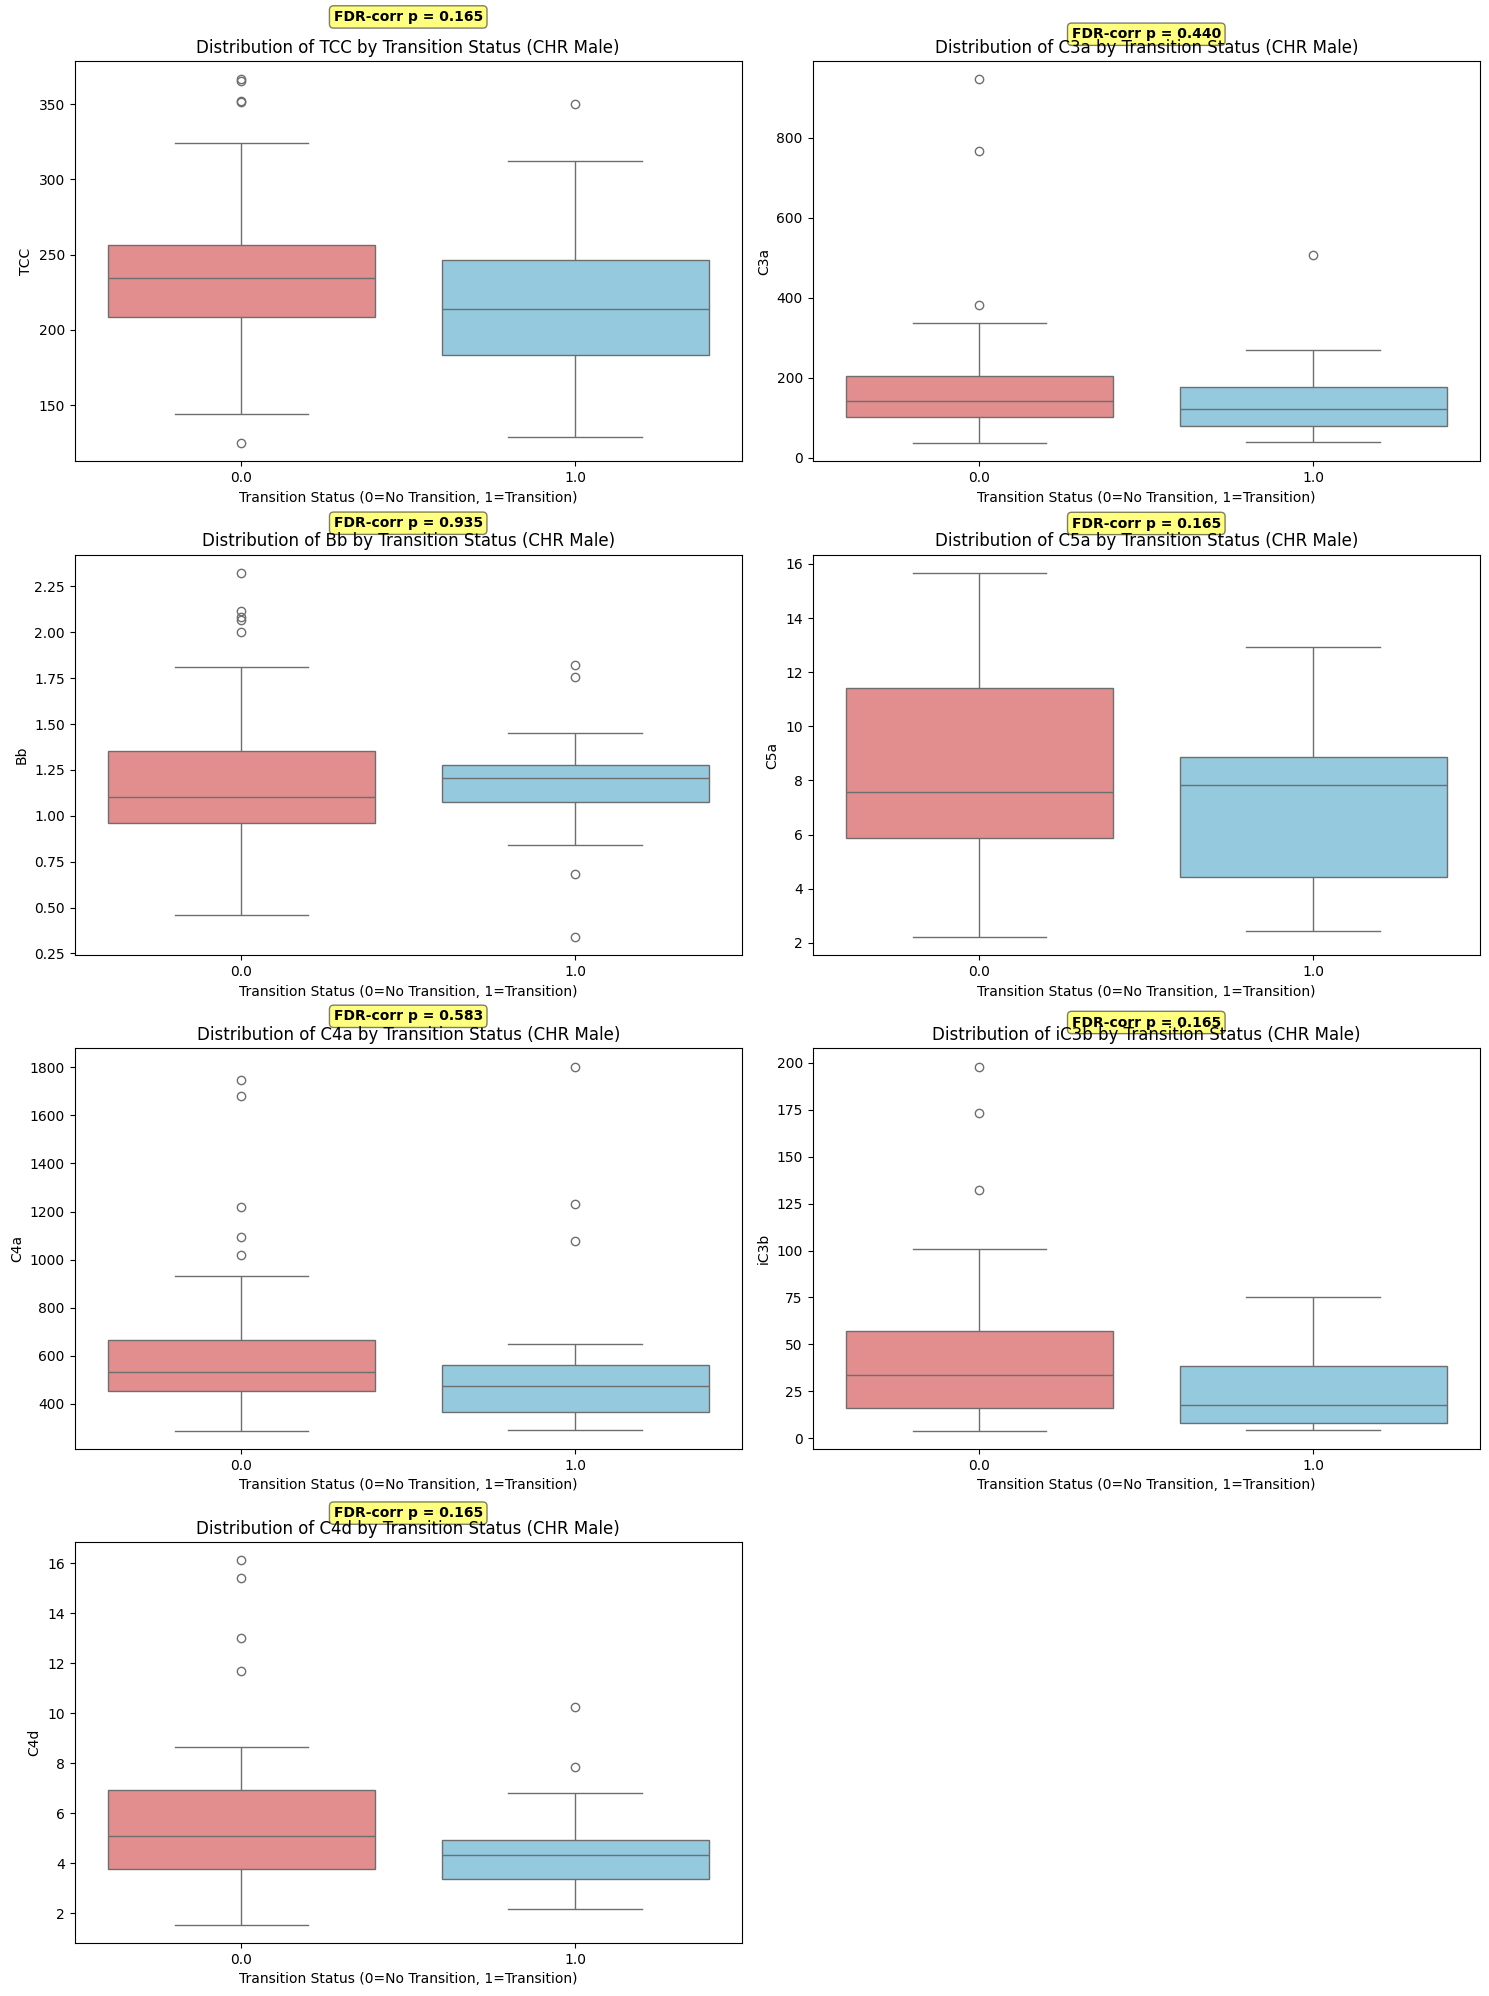

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # For np.nan handling

# Define the columns for visualization
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Ensure df_chr_male and p_corrected_male_ancova_cov are available from previous cells
# (Assuming previous cells successfully ran and these variables are in scope)

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Male' subgroup (annotated with FDR-corrected ANCOVA p-values)...")

# Create a dictionary for FDR-corrected p-values for male subgroup
p_corrected_dict_male_ancova_cov = dict(zip(columns_for_fdr_male_ancova_cov, p_corrected_male_ancova_cov))

# Calculate number of rows and columns for subplots
num_cols = 2
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='Transition', y=col, data=df_chr_male, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (CHR Male)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_male_ancova_cov:
        p_value_fdr = p_corrected_dict_male_ancova_cov[col]

        # Get max_val for current column, handling potential empty data after filtering
        if not df_chr_male[col].dropna().empty:
            max_val = df_chr_male[col].max() * 1.1
        else:
            max_val = 1.0 # Default if no data

        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data, no variability)
        if not df_chr_male[col].dropna().empty:
            max_val = df_chr_male[col].max() * 1.1
        else:
            max_val = 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Visualizing Differences within CHR Female Subgroup: Transition vs. No Transition (with FDR-corrected ANCOVA p-values)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Female' subgroup (annotated with FDR-corrected ANCOVA p-values)...


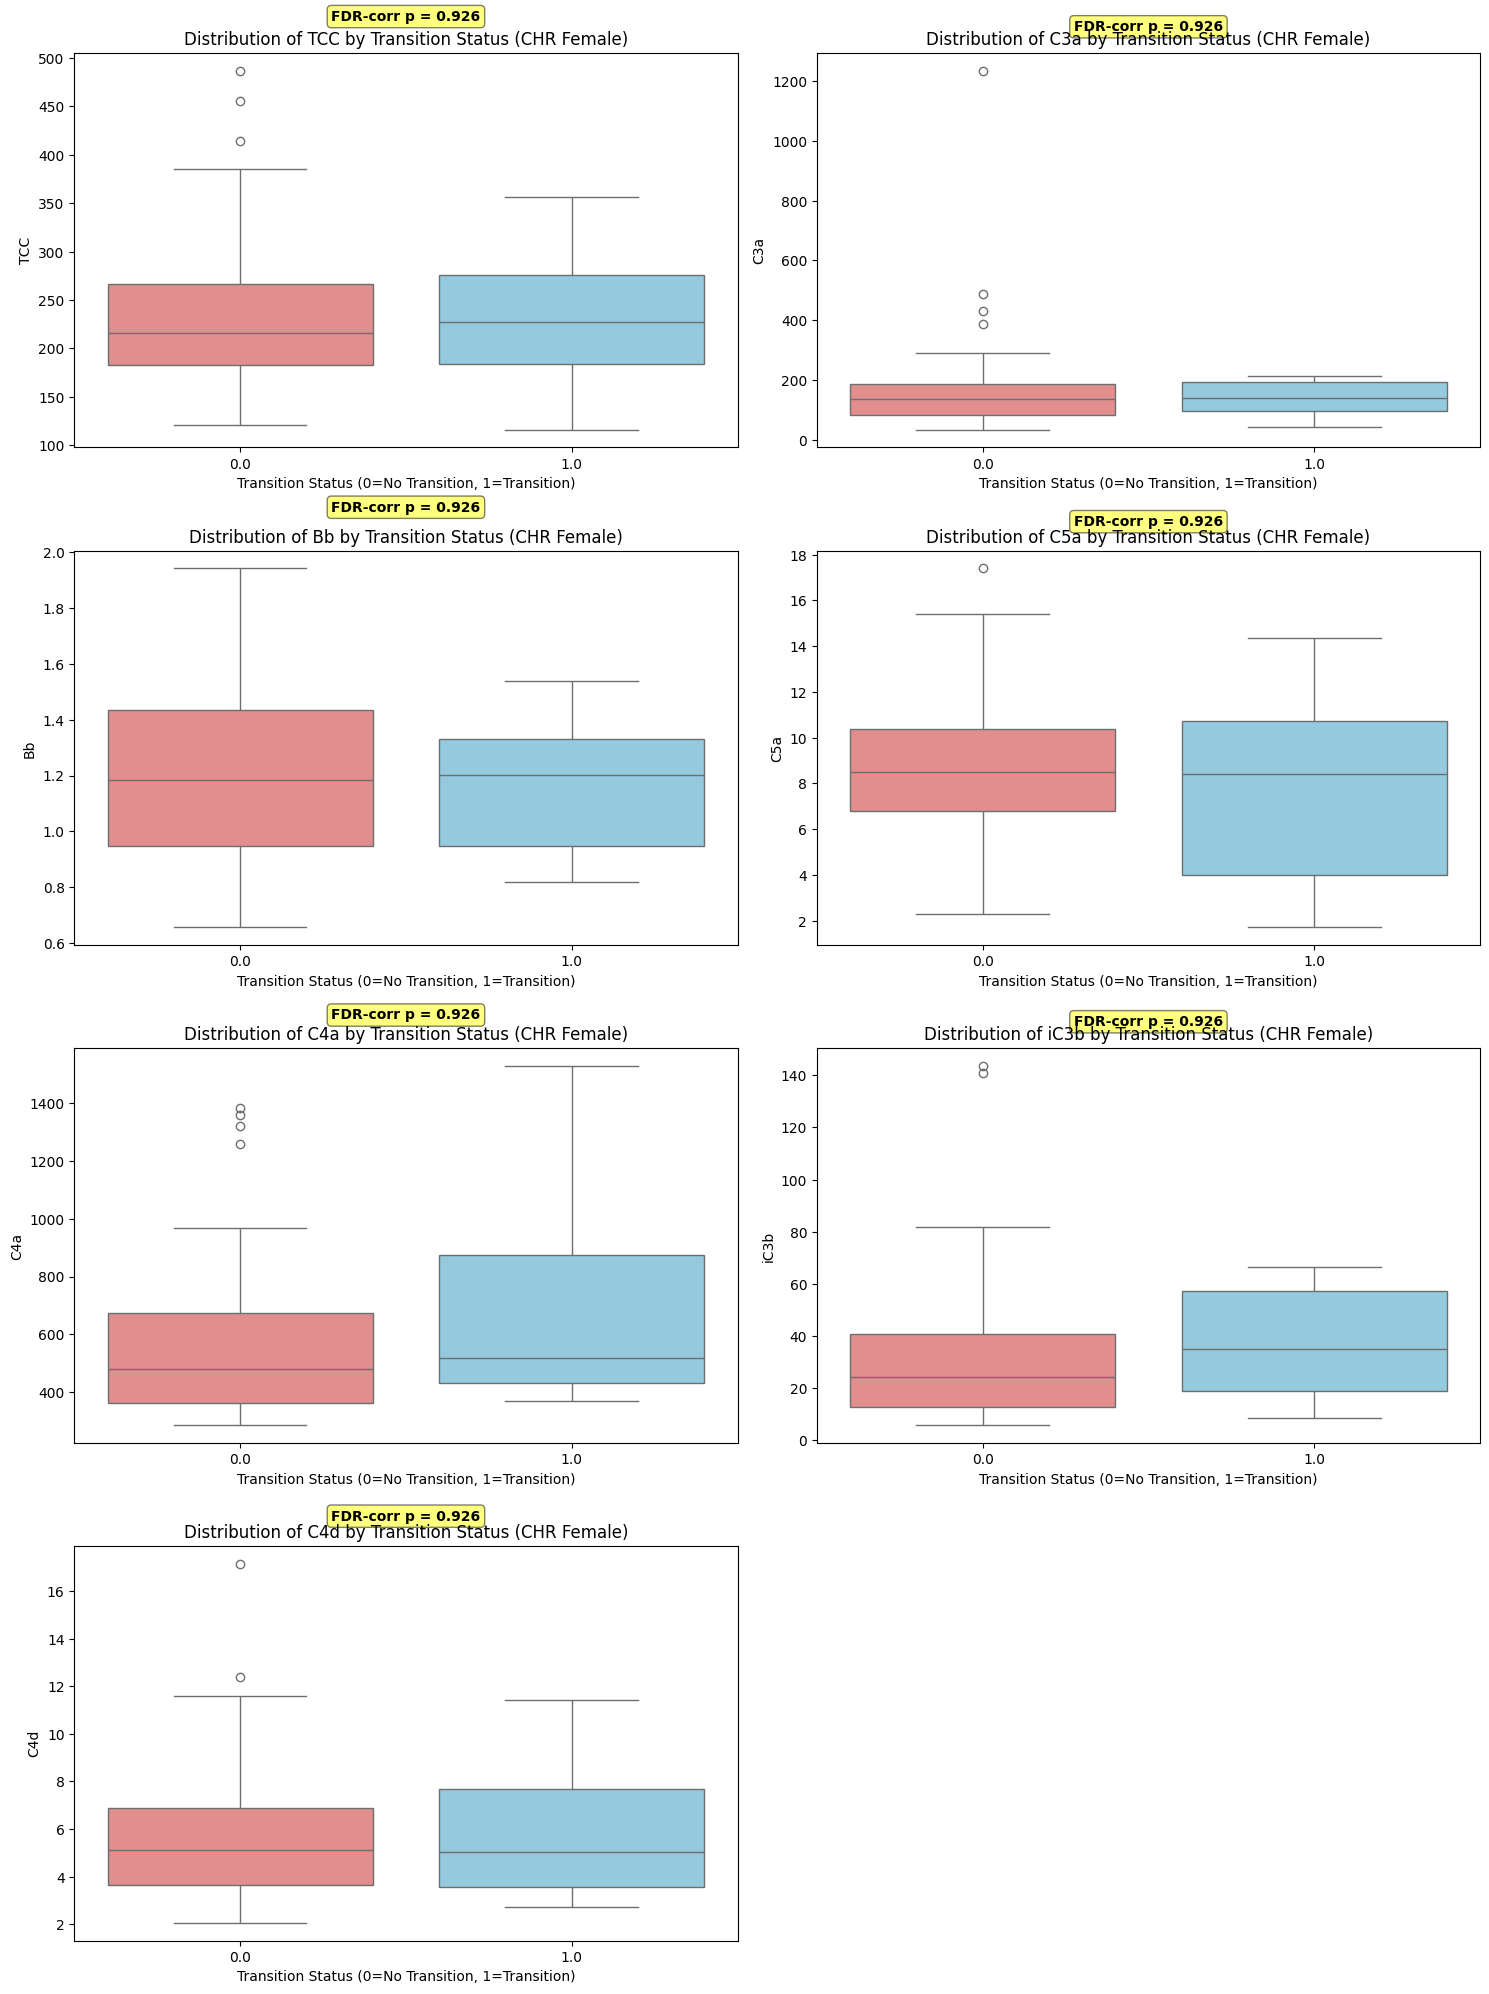

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # For np.nan handling

# Define the columns for visualization
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Ensure df_chr_female and p_corrected_female_ancova_cov are available from previous cells
# (Assuming previous cells successfully ran and these variables are in scope)

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Female' subgroup (annotated with FDR-corrected ANCOVA p-values)...")

# Create a dictionary for FDR-corrected p-values for female subgroup
p_corrected_dict_female_ancova_cov = dict(zip(columns_for_fdr_female_ancova_cov, p_corrected_female_ancova_cov))

# Calculate number of rows and columns for subplots
num_cols = 2
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='Transition', y=col, data=df_chr_female, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (CHR Female)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_female_ancova_cov:
        p_value_fdr = p_corrected_dict_female_ancova_cov[col]

        # Get max_val for current column, handling potential empty data after filtering
        if not df_chr_female[col].dropna().empty:
            max_val = df_chr_female[col].max() * 1.1
        else:
            max_val = 1.0 # Default if no data

        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data, no variability)
        if not df_chr_female[col].dropna().empty:
            max_val = df_chr_female[col].max() * 1.1
        else:
            max_val = 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Statistical Analysis: Comparing Transition vs. No Transition within CHR (accounting for Sex, Age, Race, tobaccoUse, and marijuanaUse, with FDR Correction)

In [48]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction),\naccounting for Sex, Age, Race, tobaccoUse, and marijuanaUse:\n")

# Collect p-values for FDR correction
original_p_values_all_cov = []
columns_for_fdr_all_cov = []

for col in columns_to_analyze:
    # Define the model formula with all specified covariates
    formula = f"{col} ~ C(Transition) + Age + C(Sex) + C(Race) + C(tobaccoUse) + C(marijuanaUse)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_only[[col, 'Transition', 'Age', 'Sex', 'Race', 'tobaccoUse', 'marijuanaUse']].dropna()

    if not model_df.empty and model_df['Transition'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(Transition)[T.1.0]' in model.pvalues.index:
                p_value = model.pvalues['C(Transition)[T.1.0]']
                original_p_values_all_cov.append(p_value)
                columns_for_fdr_all_cov.append(col)
        except Exception as e:
            print(f"  Could not fit model for {col}: {e}\n")

# Apply FDR correction
if original_p_values_all_cov:
    reject_all_cov, p_corrected_all_cov, _, _ = multipletests(original_p_values_all_cov, alpha=0.05, method='fdr_bh')

    # Display results
    print("--- FDR Corrected P-values for Transition (in CHR group, with all covariates) ---")
    results_all_cov = pd.DataFrame({
        'Column': columns_for_fdr_all_cov,
        'Original P-value': original_p_values_all_cov,
        'FDR-corrected P-value': p_corrected_all_cov,
        'Significant (FDR < 0.05)': reject_all_cov
    })
    results_all_cov['Original P-value'] = results_all_cov['Original P-value'].map(lambda x: f"{x:.3f}")
    results_all_cov['FDR-corrected P-value'] = results_all_cov['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results_all_cov)

    # Summarize overall conclusion
    if any(reject_all_cov):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference in Transition status after accounting for all covariates.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for all covariates (FDR >= 0.05).")
else:
    print("No sufficient data to perform FDR correction for Transition status across markers with all covariates.")

Comparing 'Transition' vs 'No Transition' within the 'CHR' group (with FDR correction),
accounting for Sex, Age, Race, tobaccoUse, and marijuanaUse:

--- FDR Corrected P-values for Transition (in CHR group, with all covariates) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.149,0.349,False
1,C3a,0.256,0.359,False
2,Bb,0.746,0.871,False
3,C5a,0.073,0.349,False
4,C4a,0.977,0.977,False
5,iC3b,0.103,0.349,False
6,C4d,0.214,0.359,False



Overall Conclusion (FDR-corrected): No significant difference in Transition status found for any marker after accounting for all covariates (FDR >= 0.05).


### Visualizing Differences within CHR group: Transition vs. No Transition (with all covariates and FDR-corrected ANCOVA p-values)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR' group (annotated with FDR-corrected ANCOVA p-values, accounting for all covariates)...


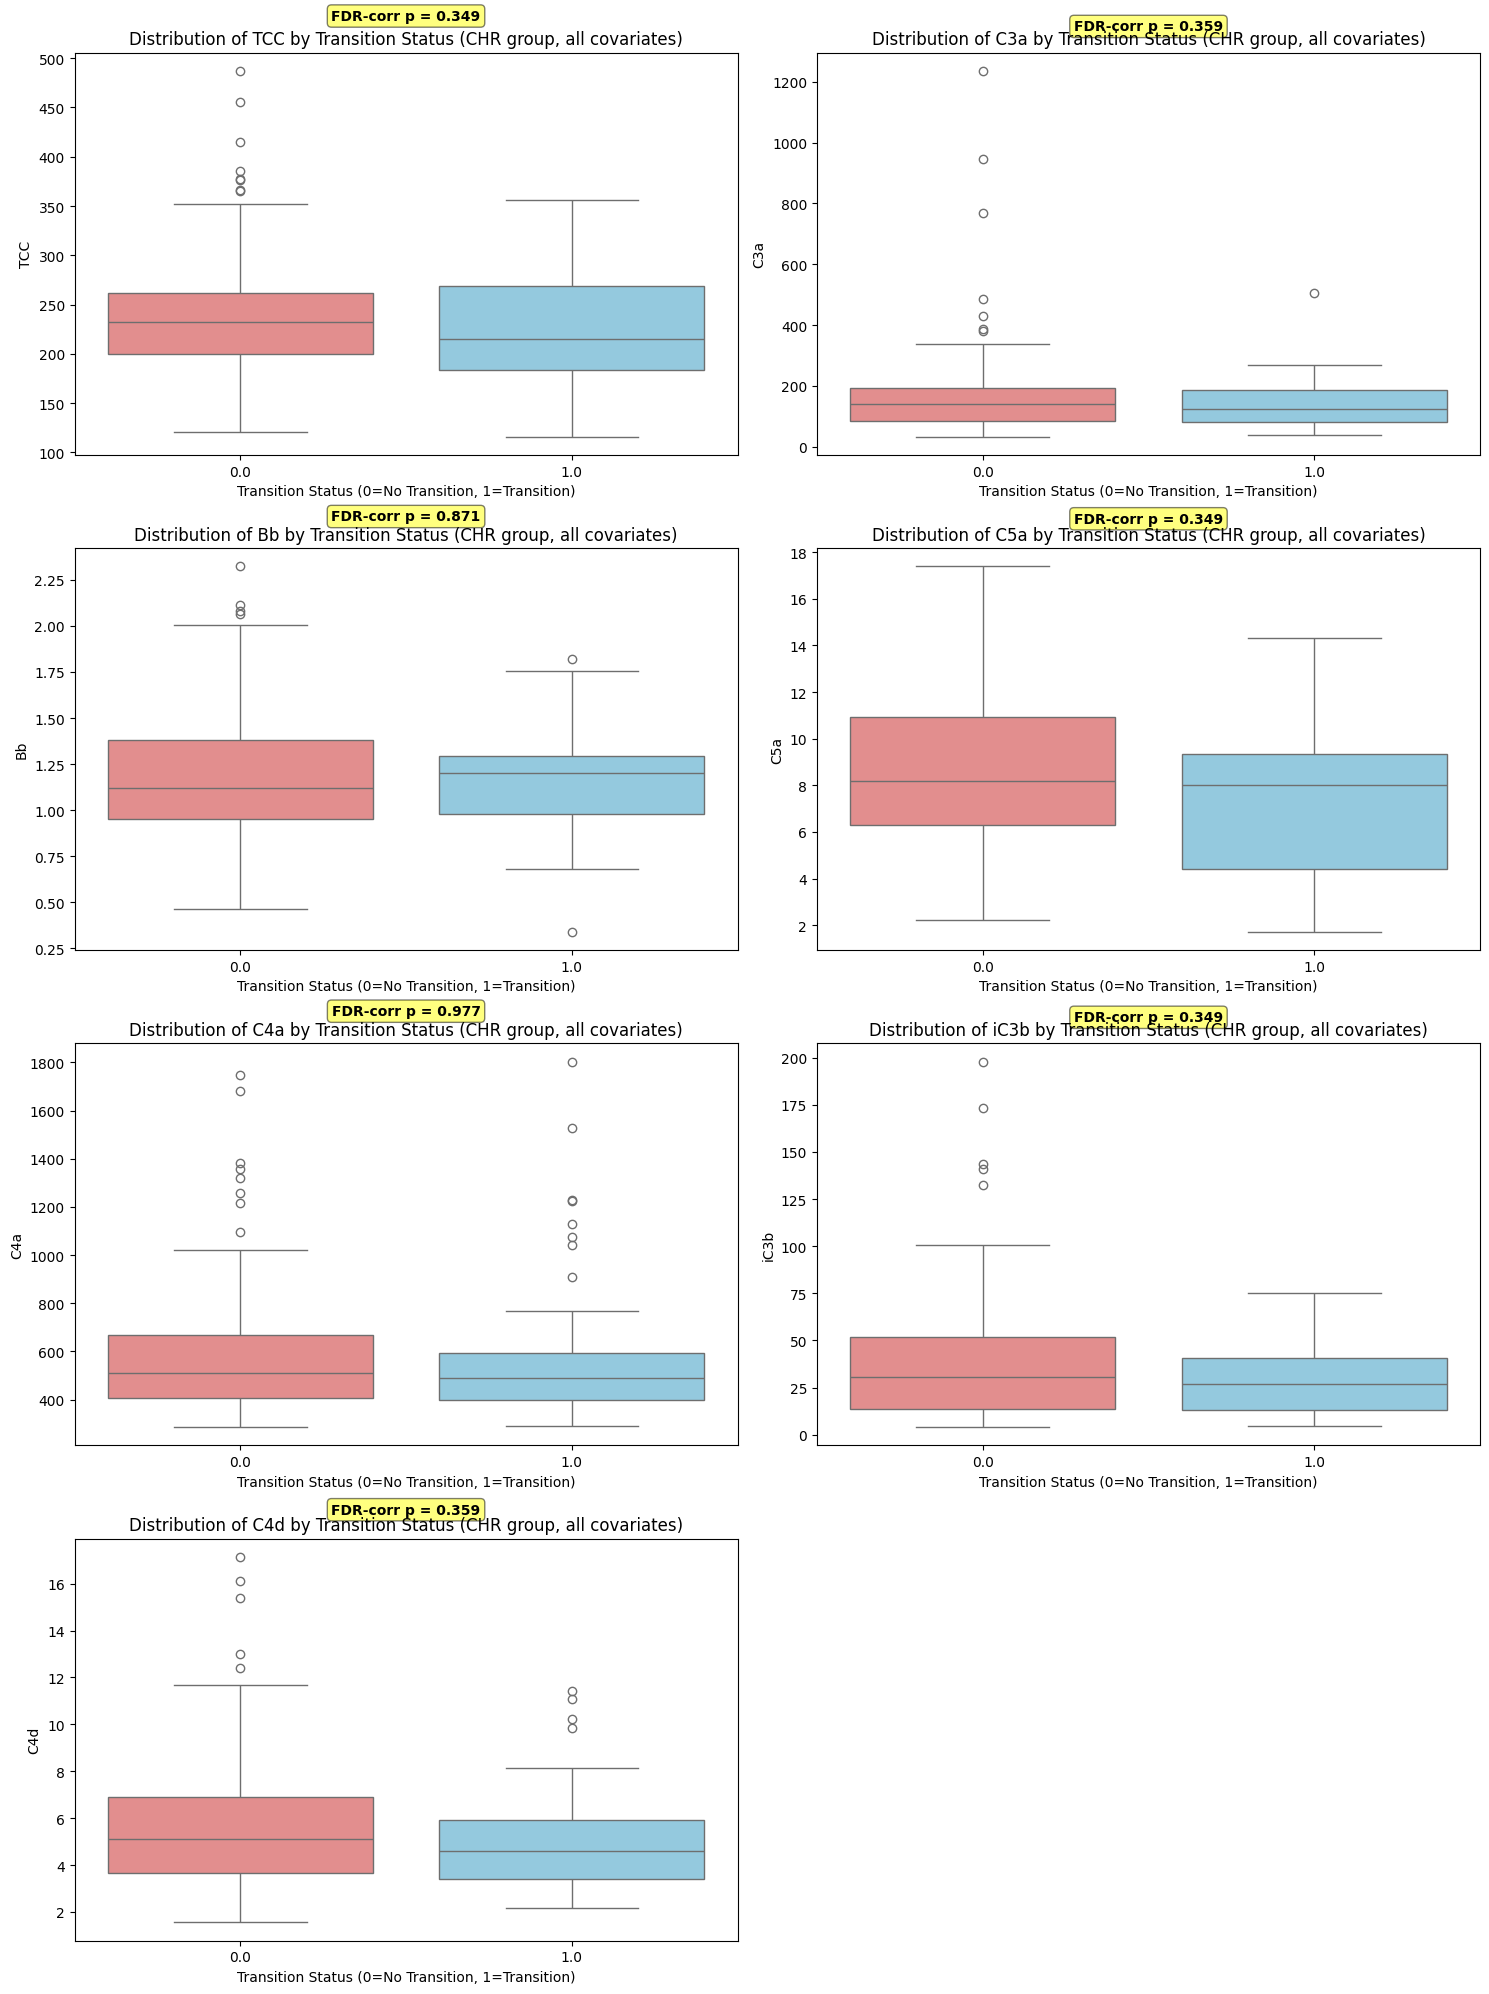

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define the columns for visualization
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR' group (annotated with FDR-corrected ANCOVA p-values, accounting for all covariates)...")

# Create a dictionary for FDR-corrected p-values
p_corrected_dict_all_cov = dict(zip(columns_for_fdr_all_cov, p_corrected_all_cov))

# Calculate number of rows and columns for subplots
num_cols = 2
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='Transition', y=col, data=df_chr_only, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (CHR group, all covariates)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_all_cov:
        p_value_fdr = p_corrected_dict_all_cov[col]

        # Get max_val for current column, handling potential empty data after filtering
        if not df_chr_only[col].dropna().empty:
            max_val = df_chr_only[col].max() * 1.1
        else:
            max_val = 1.0 # Default if no data

        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data, no variability)
        if not df_chr_only[col].dropna().empty:
            max_val = df_chr_only[col].max() * 1.1
        else:
            max_val = 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Visualizing Differences within CHR Male Subgroup: Transition vs. No Transition (with FDR-corrected ANCOVA p-values)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Male' subgroup (annotated with FDR-corrected ANCOVA p-values)...


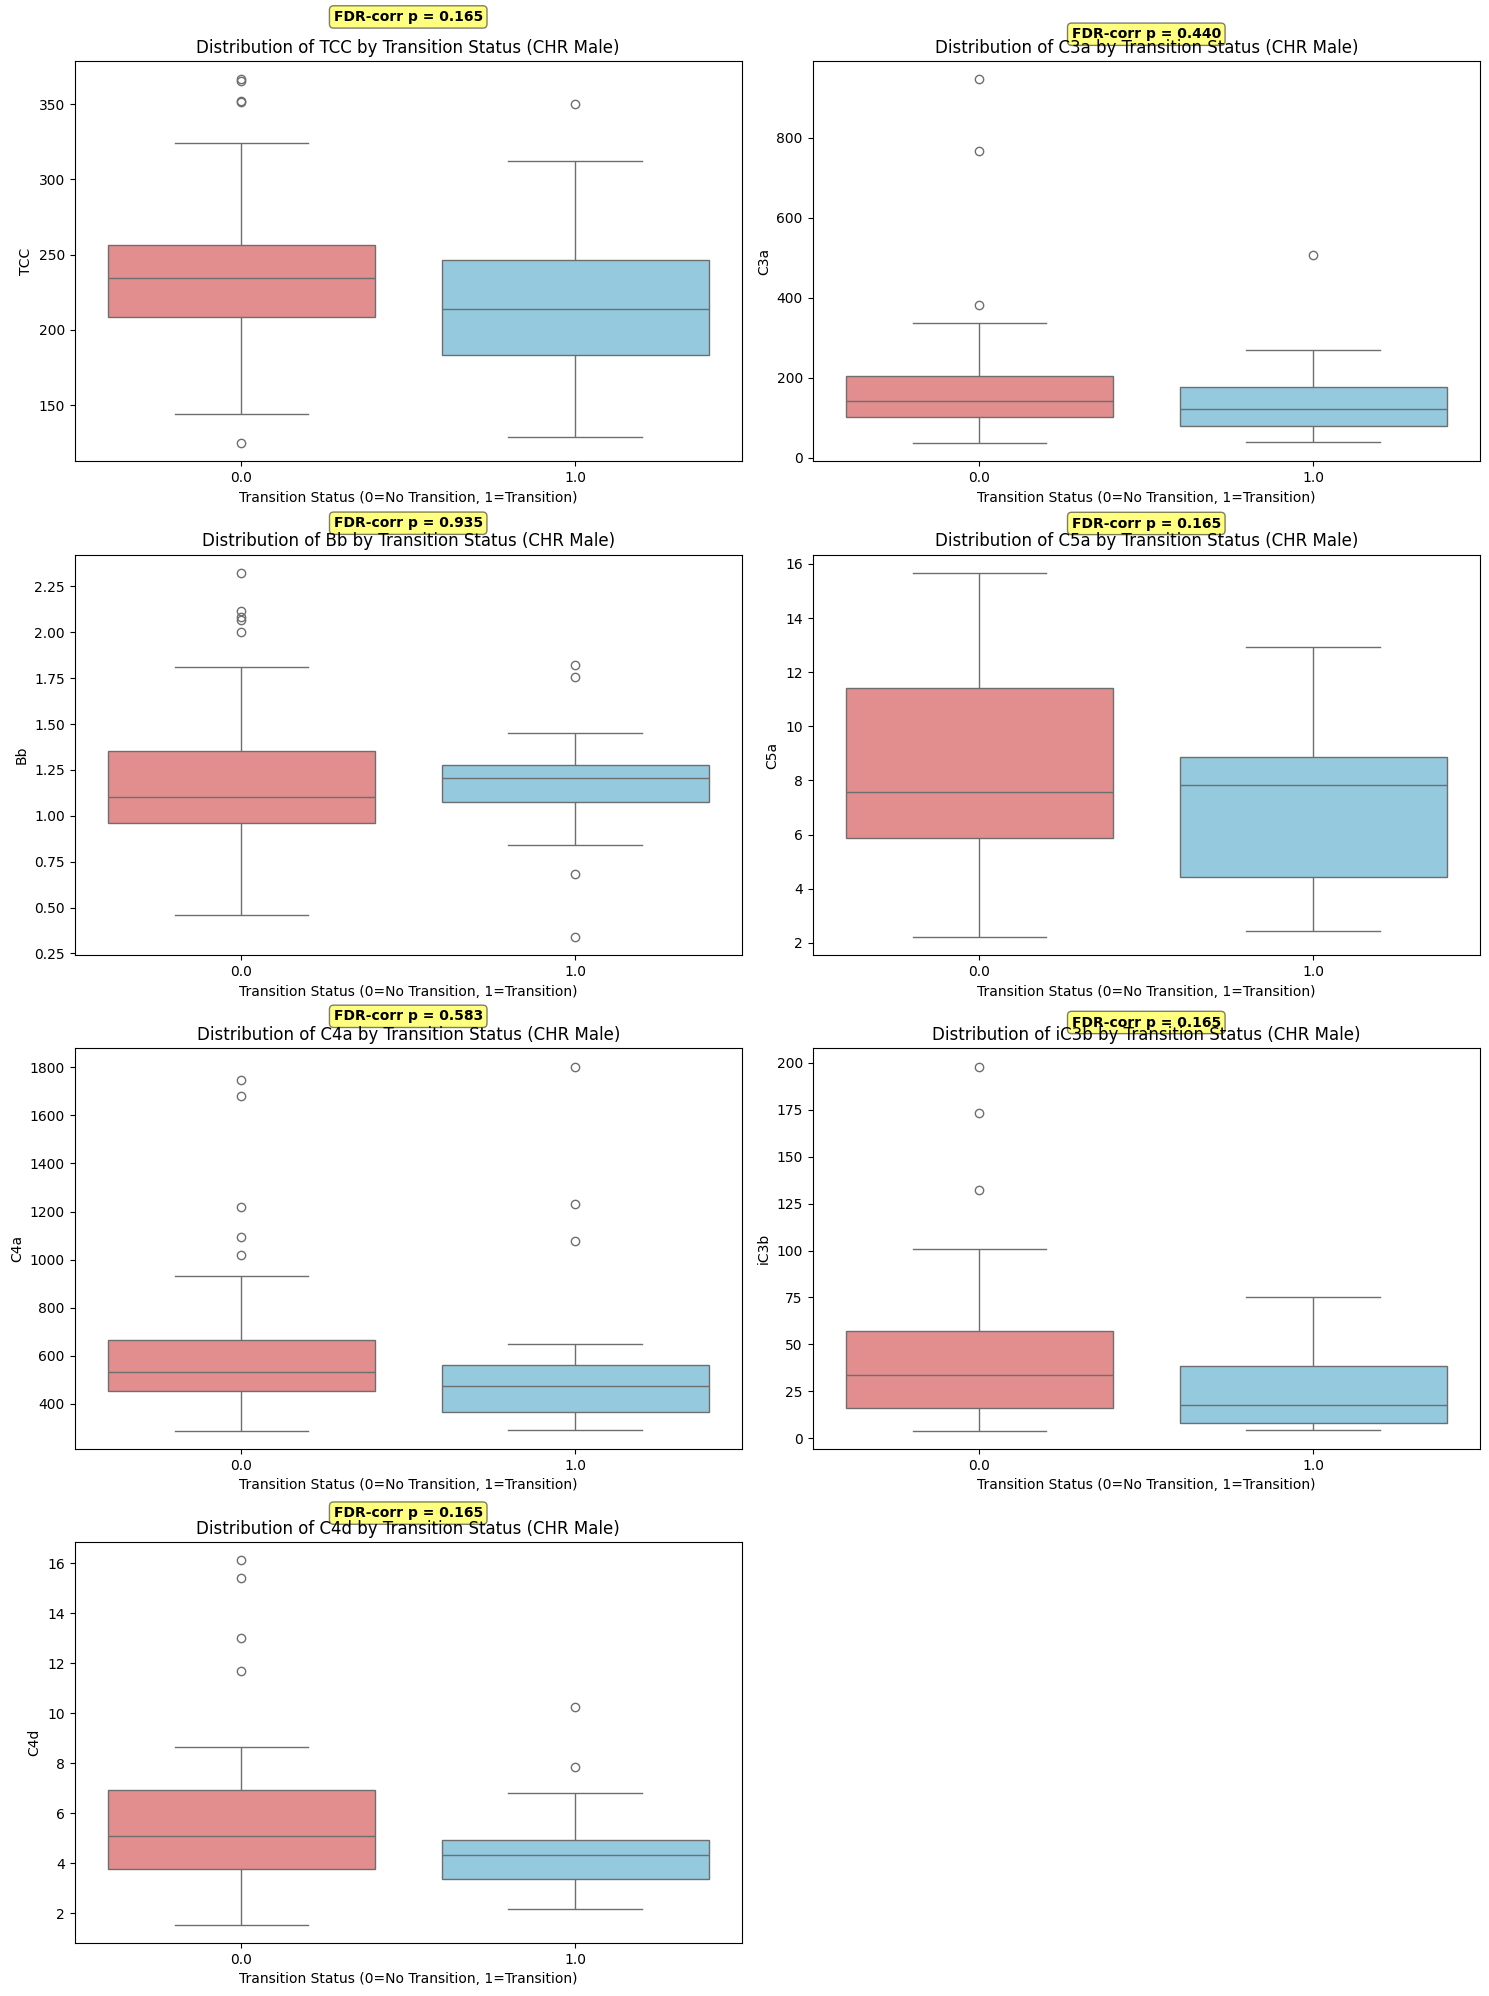

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # For np.nan handling

# Define the columns for visualization
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Ensure df_chr_male and p_corrected_male_ancova_cov are available from previous cells
# (Assuming previous cells successfully ran and these variables are in scope)

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Male' subgroup (annotated with FDR-corrected ANCOVA p-values)...")

# Create a dictionary for FDR-corrected p-values for male subgroup
p_corrected_dict_male_ancova_cov = dict(zip(columns_for_fdr_male_ancova_cov, p_corrected_male_ancova_cov))

# Calculate number of rows and columns for subplots
num_cols = 2
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='Transition', y=col, data=df_chr_male, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (CHR Male)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_male_ancova_cov:
        p_value_fdr = p_corrected_dict_male_ancova_cov[col]

        # Get max_val for current column, handling potential empty data after filtering
        if not df_chr_male[col].dropna().empty:
            max_val = df_chr_male[col].max() * 1.1
        else:
            max_val = 1.0 # Default if no data

        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data, no variability)
        if not df_chr_male[col].dropna().empty:
            max_val = df_chr_male[col].max() * 1.1
        else:
            max_val = 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Visualizing Differences within CHR Female Subgroup: Transition vs. No Transition (with FDR-corrected ANCOVA p-values)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Female' subgroup (annotated with FDR-corrected ANCOVA p-values)...


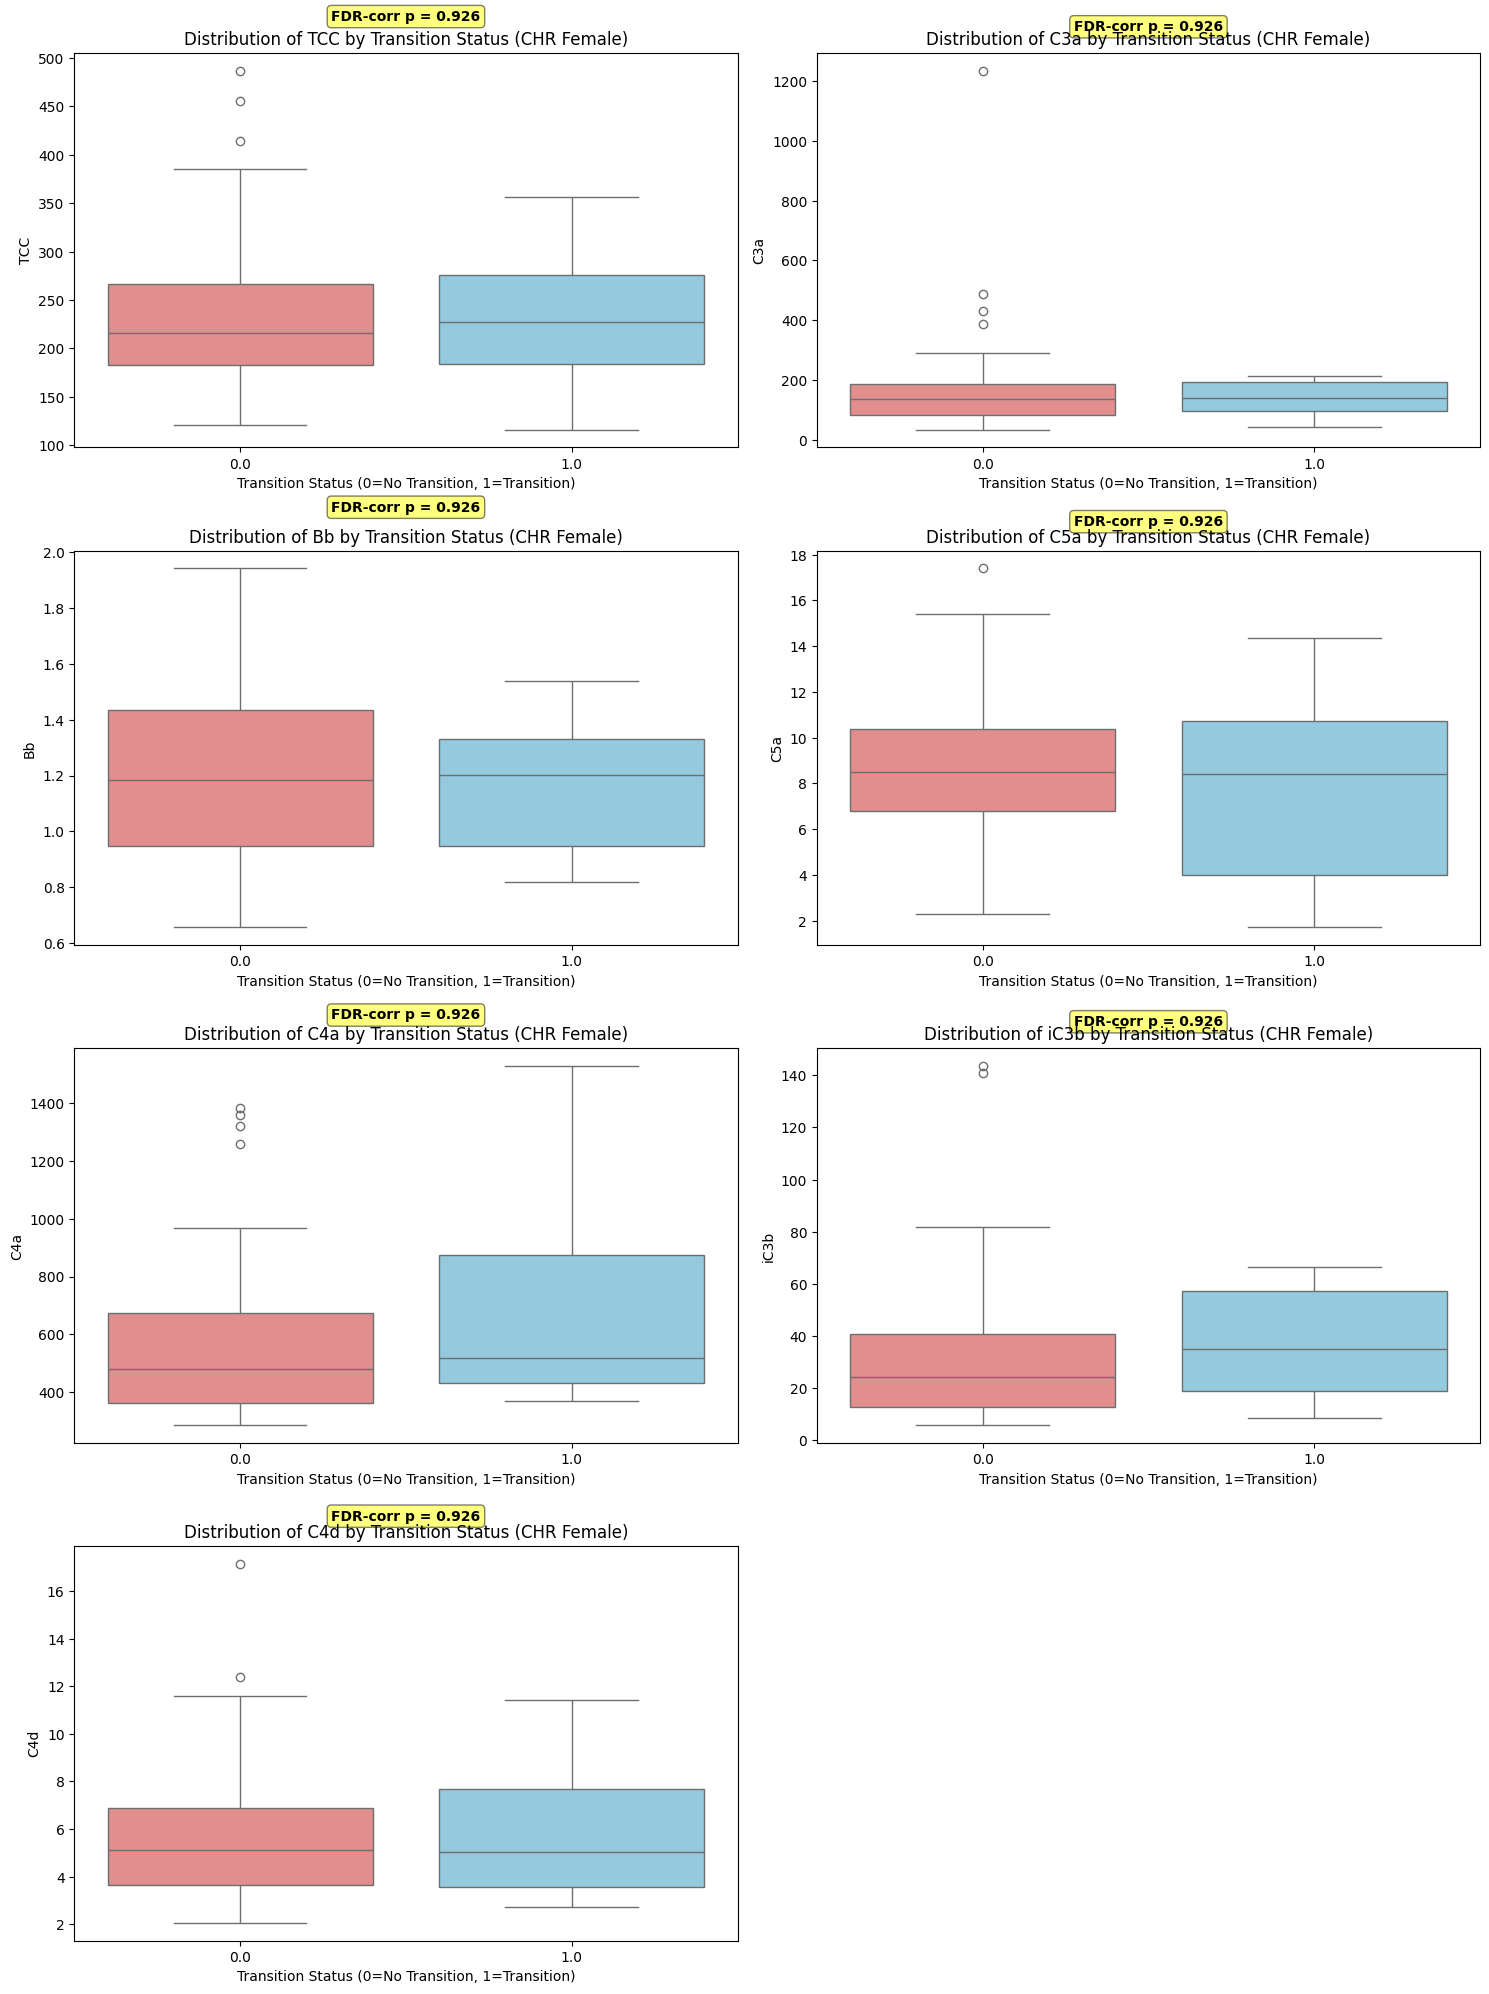

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # For np.nan handling

# Define the columns for visualization
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Ensure df_chr_female and p_corrected_female_ancova_cov are available from previous cells
# (Assuming previous cells successfully ran and these variables are in scope)

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR Female' subgroup (annotated with FDR-corrected ANCOVA p-values)...")

# Create a dictionary for FDR-corrected p-values for female subgroup
p_corrected_dict_female_ancova_cov = dict(zip(columns_for_fdr_female_ancova_cov, p_corrected_female_ancova_cov))

# Calculate number of rows and columns for subplots
num_cols = 2
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='Transition', y=col, data=df_chr_female, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (CHR Female)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_female_ancova_cov:
        p_value_fdr = p_corrected_dict_female_ancova_cov[col]

        # Get max_val for current column, handling potential empty data after filtering
        if not df_chr_female[col].dropna().empty:
            max_val = df_chr_female[col].max() * 1.1
        else:
            max_val = 1.0 # Default if no data

        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data, no variability)
        if not df_chr_female[col].dropna().empty:
            max_val = df_chr_female[col].max() * 1.1
        else:
            max_val = 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Statistical Analysis: Comparing UC and CHR groups

In [16]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests # Import for FDR correction

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Separate data into UC and CHR groups
df_uc = df[df['TYPE'] == 'UC']
df_chr = df[df['TYPE'] == 'CHR']

print("Comparing 'UC' vs 'CHR' groups (with FDR correction):\n")

# Collect p-values for FDR correction
p_values = []
columns_with_sufficient_data = []

for col in columns_to_analyze:
    uc_values = df_uc[col].dropna()
    chr_values = df_chr[col].dropna()

    if len(uc_values) > 1 and len(chr_values) > 1:
        t_stat, p_value = stats.ttest_ind(uc_values, chr_values, equal_var=False) # Welch's t-test
        p_values.append(p_value)
        columns_with_sufficient_data.append(col)
    else:
        # Add a placeholder for columns without sufficient data, if needed for consistent indexing
        # For now, we'll just skip them in the p_values list and handle reporting separately
        pass

# Apply FDR correction (Benjamini-Hochberg method)
if p_values:
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    p_corrected_dict = dict(zip(columns_with_sufficient_data, p_corrected))
    reject_dict = dict(zip(columns_with_sufficient_data, reject))
else:
    p_corrected_dict = {}
    reject_dict = {}

# Perform independent t-tests and report with FDR-corrected p-values
p_values_original_report = []
for col in columns_to_analyze:
    uc_values = df_uc[col].dropna()
    chr_values = df_chr[col].dropna()

    if len(uc_values) > 1 and len(chr_values) > 1:
        t_stat, p_value_original = stats.ttest_ind(uc_values, chr_values, equal_var=False) # Welch's t-test
        p_values_original_report.append(p_value_original)

        print(f"--- {col} ---")
        print(f"Mean (UC): {uc_values.mean():.2f}")
        print(f"Mean (CHR): {chr_values.mean():.2f}")
        print(f"T-statistic: {t_stat:.2f}")
        print(f"Original P-value: {p_value_original:.3f}")

        if col in p_corrected_dict:
            p_value_fdr = p_corrected_dict[col]
            print(f"FDR-corrected P-value: {p_value_fdr:.3f}")
            if reject_dict[col]:
                print("Conclusion (FDR-corrected): Significant difference (p_fdr < 0.05)\n")
            else:
                print("Conclusion (FDR-corrected): No significant difference (p_fdr >= 0.05)\n")
        else:
            print("FDR correction could not be applied for this column.\n")
    else:
        print(f"--- {col} ---")
        print(f"Not enough data in one or both groups to perform t-test for {col}.\n")

Comparing 'UC' vs 'CHR' groups (with FDR correction):

--- TCC ---
Mean (UC): 271.08
Mean (CHR): 235.05
T-statistic: 2.22
Original P-value: 0.029
FDR-corrected P-value: 0.051
Conclusion (FDR-corrected): No significant difference (p_fdr >= 0.05)

--- C3a ---
Mean (UC): 289.13
Mean (CHR): 164.00
T-statistic: 4.77
Original P-value: 0.000
FDR-corrected P-value: 0.000
Conclusion (FDR-corrected): Significant difference (p_fdr < 0.05)

--- Bb ---
Mean (UC): 1.09
Mean (CHR): 1.19
T-statistic: -2.35
Original P-value: 0.020
FDR-corrected P-value: 0.047
Conclusion (FDR-corrected): Significant difference (p_fdr < 0.05)

--- C5a ---
Mean (UC): 8.68
Mean (CHR): 8.19
T-statistic: 1.06
Original P-value: 0.291
FDR-corrected P-value: 0.322
Conclusion (FDR-corrected): No significant difference (p_fdr >= 0.05)

--- C4a ---
Mean (UC): 641.18
Mean (CHR): 592.17
T-statistic: 0.99
Original P-value: 0.322
FDR-corrected P-value: 0.322
Conclusion (FDR-corrected): No significant difference (p_fdr >= 0.05)

--- iC

### Visualizing the differences between UC and CHR groups

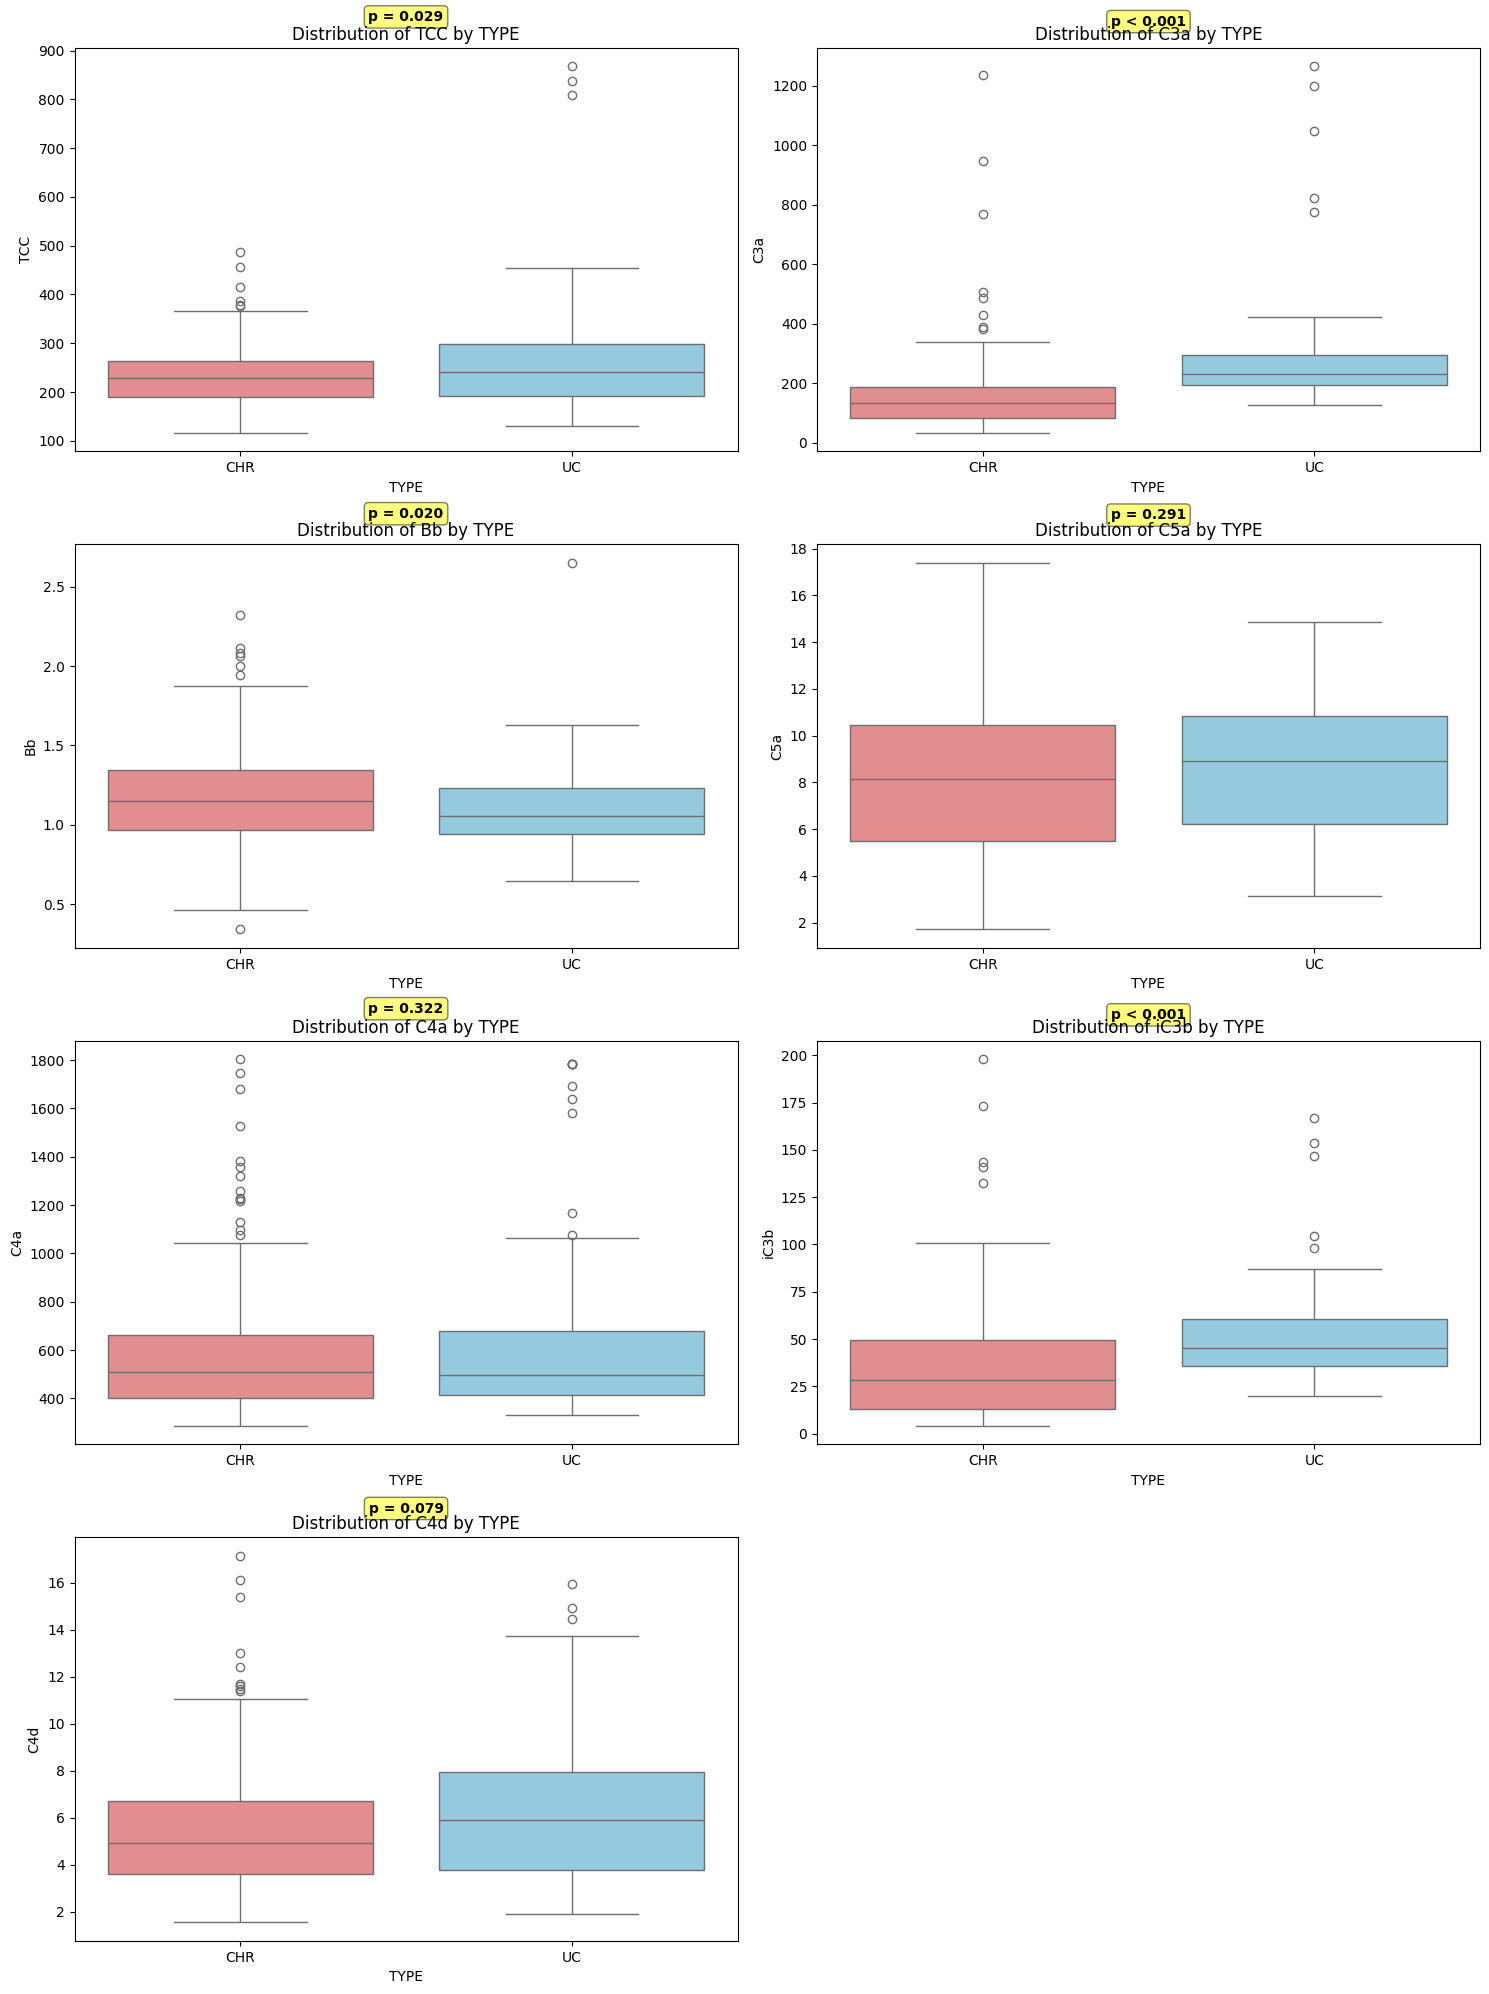

In [18]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for visualization and analysis
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Separate data into UC and CHR groups
df_uc = df[df['TYPE'] == 'UC']
df_chr = df[df['TYPE'] == 'CHR']

# Calculate number of rows and columns for subplots
num_cols = 2 # We want 2 columns for the plots
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(15, 5 * num_rows)) # Adjust figure size for multiple plots

# Create box plots for each column comparing UC and CHR
for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1) # Position the subplot
    sns.boxplot(x='TYPE', y=col, data=df, hue='TYPE', palette={'UC': 'skyblue', 'CHR': 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by TYPE')
    plt.xlabel('TYPE')
    plt.ylabel(col)

    # Perform t-test for annotation
    uc_values = df_uc[col].dropna()
    chr_values = df_chr[col].dropna()

    if len(uc_values) > 1 and len(chr_values) > 1:
        t_stat, p_value = stats.ttest_ind(uc_values, chr_values, equal_var=False) # Welch's t-test

        # Annotate with p-value
        max_val = df[col].max() * 1.1 # Get max value for current column and add some buffer
        p_value_text = f"p = {p_value:.3f}"
        if p_value < 0.001: # For very small p-values
            p_value_text = "p < 0.001"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where t-test can't be performed due to insufficient data
        max_val = df[col].max() * 1.1 if not df[col].empty else 1.0
        plt.text(0.5, max_val, "Insufficient data", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Visualizing differences within CHR group: Transition vs. No Transition (without covariates)

Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR' group (without covariates)...


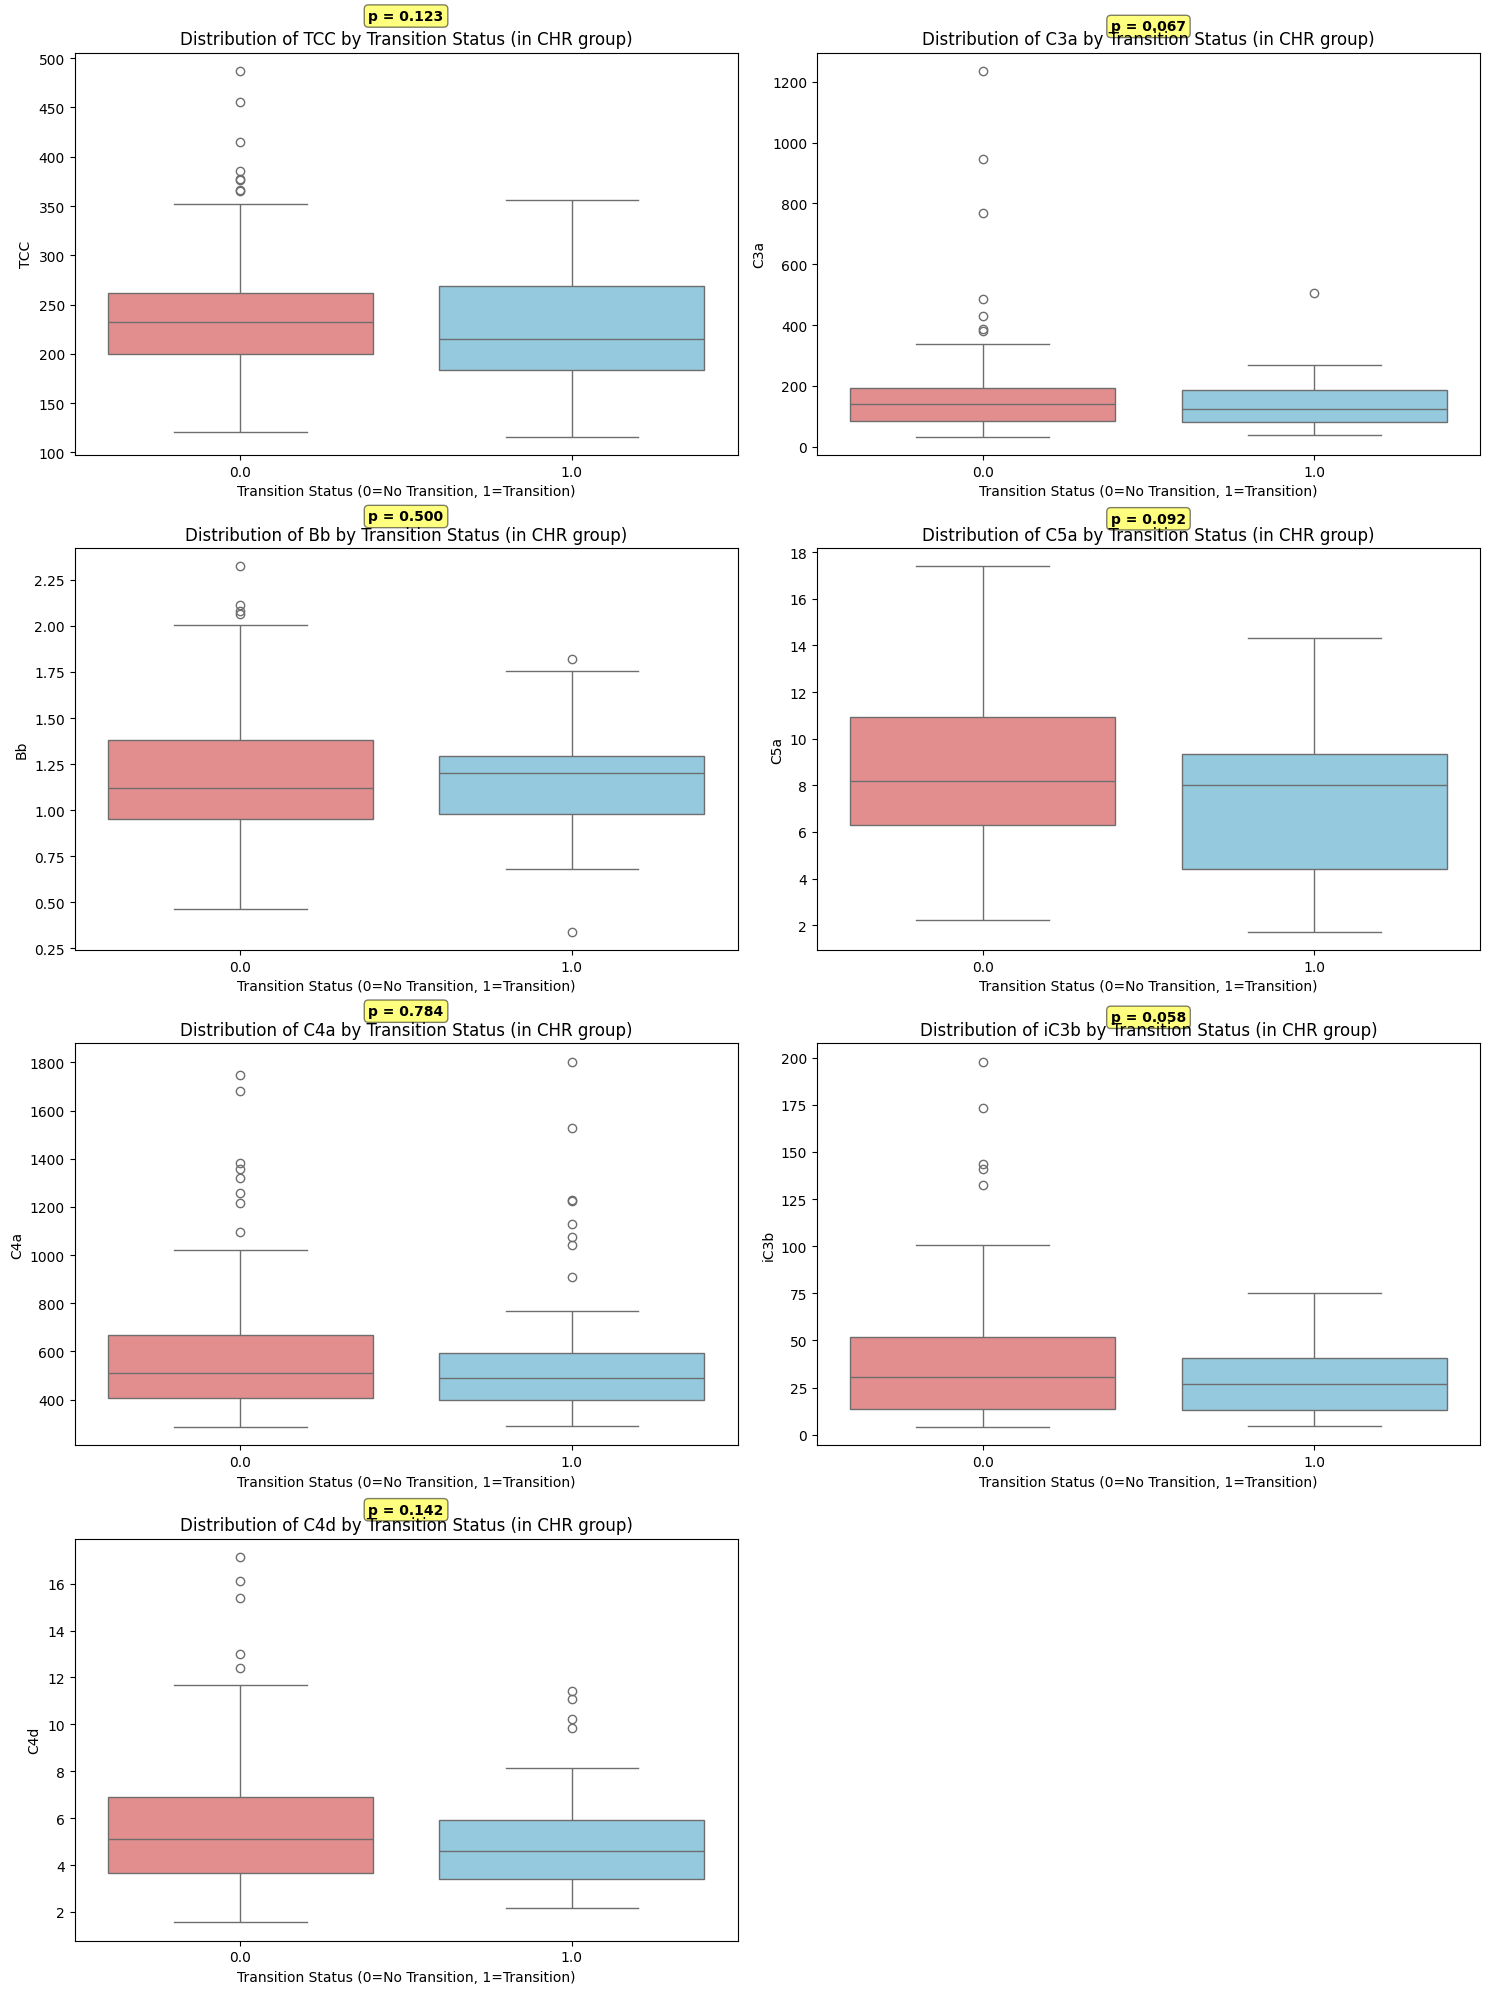

In [22]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for visualization and analysis
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

# Separate data into Transition (1) and No Transition (0) groups within CHR
df_transition = df_chr_only[df_chr_only['Transition'] == 1]
df_no_transition = df_chr_only[df_chr_only['Transition'] == 0]

# Calculate number of rows and columns for subplots
num_cols = 2 # We want 2 columns for the plots
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(15, 5 * num_rows)) # Adjust figure size for multiple plots

print("Generating box plots comparing 'Transition (1)' vs 'No Transition (0)' within the 'CHR' group (without covariates)...")

# Create box plots for each column comparing Transition and No Transition within CHR
for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1) # Position the subplot
    sns.boxplot(x='Transition', y=col, data=df_chr_only, hue='Transition', palette={1: 'skyblue', 0: 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Transition Status (in CHR group)')
    plt.xlabel('Transition Status (0=No Transition, 1=Transition)')
    plt.ylabel(col)

    # Perform t-test for annotation
    transition_values = df_transition[col].dropna()
    no_transition_values = df_no_transition[col].dropna()

    if len(transition_values) > 1 and len(no_transition_values) > 1:
        t_stat, p_value = stats.ttest_ind(transition_values, no_transition_values, equal_var=False) # Welch's t-test

        # Annotate with p-value
        max_val = df_chr_only[col].max() * 1.1 # Get max value for current column and add some buffer
        p_value_text = f"p = {p_value:.3f}"
        if p_value < 0.001: # For very small p-values
            p_value_text = "p < 0.001"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where t-test can't be performed due to insufficient data
        max_val = df_chr_only[col].max() * 1.1 if not df_chr_only[col].empty else 1.0
        plt.text(0.5, max_val, "Insufficient data", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

### Statistical Analysis: Comparing Transition vs. No Transition within CHR, accounting for Sex, Age, and Race

In [32]:
import statsmodels.formula.api as smf

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

# Filter for the CHR group first
df_chr_only = df[df['TYPE'] == 'CHR'].copy()

print("Comparing 'Transition' vs 'No Transition' within the 'CHR' group, accounting for Sex, Age, and Race:\n")

for col in columns_to_analyze:
    # Define the model formula. C() treats a variable as categorical.
    formula = f"{col} ~ C(Transition) + C(Sex) + Age + C(Race)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df_chr_only[[col, 'Transition', 'Sex', 'Age', 'Race']].dropna()

    print(f"--- {col} ---")
    if not model_df.empty:
        # Debugging: Check the unique values and counts of 'Transition' in model_df
        transition_counts = model_df['Transition'].value_counts()
        print(f"  Transition value counts in model_df: {transition_counts.to_dict()}")

        if model_df['Transition'].nunique() > 1:
            try:
                model = smf.ols(formula=formula, data=model_df).fit()
                # Extract the p-value for the 'C(Transition)[T.1]' coefficient
                # 'T.1' indicates the '1' level of the Transition variable, comparing to the reference level (likely '0')
                # Debugging: Print all p-value keys to find the exact name
                # print(f"  All p-value keys: {list(model.pvalues.index)}")

                if 'C(Transition)[T.1.0]' in model.pvalues.index:
                    p_value = model.pvalues['C(Transition)[T.1.0]']
                    print(f"  P-value for Transition (accounting for Sex, Age, Race): {p_value:.3f}")
                    if p_value < 0.05:
                        print("  Conclusion: Significant difference in Transition status after accounting for covariates (p < 0.05)\n")
                    else:
                        print("  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)\n")
                else:
                    print("  Transition coefficient not found in model results (possibly due to collinearity or one group having no variation after covariate adjustment).")
                    print("  All model p-values:")
                    print(model.pvalues) # Print all p-values for debugging
                    print("\n")
            except Exception as e:
                print(f"  Could not fit model for {col}: {e}\n")
        else:
            print(f"  Not enough variability in 'Transition' to fit model for {col} after dropping NaNs. Only one unique value or less after filtering.\n")
    else:
        print(f"  Not enough data to fit model for {col} after dropping NaNs. model_df is empty.\n")


Comparing 'Transition' vs 'No Transition' within the 'CHR' group, accounting for Sex, Age, and Race:

--- TCC ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.204
  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)

--- C3a ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.246
  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)

--- Bb ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.626
  Conclusion: No significant difference in Transition status after accounting for covariates (p >= 0.05)

--- C5a ---
  Transition value counts in model_df: {0.0: 108, 1.0: 45}
  P-value for Transition (accounting for Sex, Age, Race): 0.151
  Conclusion: No significant difference i

In [30]:
# Re-running the ANCOVA with the updated debug prints
%rerun bde23dbf

No lines in history match specification


In [27]:
# Re-running the ANCOVA with debug prints to understand why 'Transition' was not found
%rerun bde23dbf

No lines in history match specification


In [31]:
# Execute the ANCOVA cell directly to get the updated debug prints
get_ipython().run_cell_id('bde23dbf')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

In [35]:
# Re-running the ANCOVA with the corrected key for Transition p-value extraction
%rerun bde23dbf

No lines in history match specification


In [34]:
# Re-running the ANCOVA with the corrected key for Transition p-value extraction
get_ipython().run_cell_id('bde23dbf')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

In [39]:
print(df.columns.tolist())

['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d', 'alt_id', 'antipsychotics', 'antidepressants', 'tobaccoUse', 'tobaccoFreq', 'marijuanaUse', 'marijuanaFreq', 'TYPE', 'Transition', 'Sex', 'Age', 'Race']


In [ ]:
print(df.columns.tolist())

['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d', 'alt_id', 'antipsychotics', 'antidepressants', 'tobaccoUse', 'tobaccoFreq', 'marijuanaUse', 'marijuanaFreq', 'TYPE', 'Transition', 'Sex', 'Age', 'Race']


In [17]:
from IPython.display import Image

# Display the combined plot that was generated in cell f2733249
# The plot is shown directly when the cell is run, so no need to load from file
# Just re-run the cell to display it again.
# If you would like to see the individual plots, please let me know.

### Exploring demographic variables: Sex, Age, and Race

In [10]:
print("Information about Sex, Age, and Race columns:")
display(df[['Sex', 'Age', 'Race']].info())

print("\nUnique values and counts for 'Sex':")
display(df['Sex'].value_counts())

print("\nDescriptive statistics for 'Age':")
display(df['Age'].describe())

print("\nUnique values and counts for 'Race':")
display(df['Race'].value_counts())

Information about Sex, Age, and Race columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     232 non-null    object 
 1   Age     232 non-null    float64
 2   Race    232 non-null    object 
dtypes: float64(1), object(2)
memory usage: 5.6+ KB


None


Unique values and counts for 'Sex':


,count
Sex,
male,132
female,100



Descriptive statistics for 'Age':


,Age
count,232.000000
mean,18.172500
std,3.504765
min,12.000000
25%,16.000000
50%,17.300000
75%,20.000000
max,28.000000



Unique values and counts for 'Race':


,count
Race,
European,137
African,45
Interracial,26
Central or South American,6
South Asian,6
Southeast Asian,5
East Asian,4
First Nations,2
West or Central Asian and Middle Eastern,1


### Statistical Analysis: Comparing UC and CHR groups, accounting for Sex, Age, and Race

In [11]:
import statsmodels.formula.api as smf

# Define the columns for analysis (same as before)
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

print("Comparing 'UC' vs 'CHR' groups, accounting for Sex, Age, and Race:\n")

for col in columns_to_analyze:
    # Define the model formula. C() treats a variable as categorical.
    # Using all available data, not just UC/CHR separated dfs
    formula = f"{col} ~ C(TYPE) + C(Sex) + Age + C(Race)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    # This ensures a complete case analysis for each model
    model_df = df[[col, 'TYPE', 'Sex', 'Age', 'Race']].dropna()

    if not model_df.empty:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            print(f"--- {col} ---")
            # Extract the p-value for the 'C(TYPE)[T.UC]' coefficient
            # 'T.UC' indicates the 'UC' level of the TYPE variable, comparing to the reference level (likely 'CHR')
            if 'C(TYPE)[T.UC]' in model.pvalues:
                p_value = model.pvalues['C(TYPE)[T.UC]']
                print(f"P-value for TYPE (accounting for Sex, Age, Race): {p_value:.3f}")
                if p_value < 0.05:
                    print("Conclusion: Significant difference in TYPE after accounting for covariates (p < 0.05)\n")
                else:
                    print("Conclusion: No significant difference in TYPE after accounting for covariates (p >= 0.05)\n")
            else:
                print("TYPE not found in model results (possibly only one TYPE group after dropna or perfectly collinear).\n")

            # Optionally, you could print more of the summary
            # print(model.summary())

        except Exception as e:
            print(f"--- {col} ---")
            print(f"Could not fit model for {col}: {e}\n")
    else:
        print(f"--- {col} ---")
        print(f"Not enough data to fit model for {col} after dropping NaNs.\n")

Comparing 'UC' vs 'CHR' groups, accounting for Sex, Age, and Race:

--- TCC ---
P-value for TYPE (accounting for Sex, Age, Race): 0.008
Conclusion: Significant difference in TYPE after accounting for covariates (p < 0.05)

--- C3a ---
P-value for TYPE (accounting for Sex, Age, Race): 0.000
Conclusion: Significant difference in TYPE after accounting for covariates (p < 0.05)

--- Bb ---
P-value for TYPE (accounting for Sex, Age, Race): 0.038
Conclusion: Significant difference in TYPE after accounting for covariates (p < 0.05)

--- C5a ---
P-value for TYPE (accounting for Sex, Age, Race): 0.262
Conclusion: No significant difference in TYPE after accounting for covariates (p >= 0.05)

--- C4a ---
P-value for TYPE (accounting for Sex, Age, Race): 0.236
Conclusion: No significant difference in TYPE after accounting for covariates (p >= 0.05)

--- iC3b ---
P-value for TYPE (accounting for Sex, Age, Race): 0.000
Conclusion: Significant difference in TYPE after accounting for covariates (p < 0

### Statistical Analysis: Comparing UC and CHR groups (accounting for Sex, Age, Race, tobaccoUse, and marijuanaUse, with FDR Correction)

In [50]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Define the columns for analysis
columns_to_analyze = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

print("Comparing 'UC' vs 'CHR' groups (with FDR correction),\naccounting for Sex, Age, Race, tobaccoUse, and marijuanaUse:\n")

# Collect p-values for FDR correction
original_p_values_uc_chr_all_cov = []
columns_for_fdr_uc_chr_all_cov = []

for col in columns_to_analyze:
    # Define the model formula with all specified covariates
    formula = f"{col} ~ C(TYPE) + C(Sex) + Age + C(Race) + C(tobaccoUse) + C(marijuanaUse)"

    # Drop rows with any NaN values in the columns involved in the model for this iteration
    model_df = df[[col, 'TYPE', 'Sex', 'Age', 'Race', 'tobaccoUse', 'marijuanaUse']].dropna()

    if not model_df.empty and model_df['TYPE'].nunique() > 1:
        try:
            model = smf.ols(formula=formula, data=model_df).fit()
            if 'C(TYPE)[T.UC]' in model.pvalues.index:
                p_value = model.pvalues['C(TYPE)[T.UC]']
                original_p_values_uc_chr_all_cov.append(p_value)
                columns_for_fdr_uc_chr_all_cov.append(col)
        except Exception as e:
            print(f"  Could not fit model for {col}: {e}\n")

# Apply FDR correction
if original_p_values_uc_chr_all_cov:
    reject_uc_chr_all_cov, p_corrected_uc_chr_all_cov, _, _ = multipletests(original_p_values_uc_chr_all_cov, alpha=0.05, method='fdr_bh')

    # Display results
    print("--- FDR Corrected P-values for TYPE (UC vs CHR, with all covariates) ---")
    results_uc_chr_all_cov = pd.DataFrame({
        'Column': columns_for_fdr_uc_chr_all_cov,
        'Original P-value': original_p_values_uc_chr_all_cov,
        'FDR-corrected P-value': p_corrected_uc_chr_all_cov,
        'Significant (FDR < 0.05)': reject_uc_chr_all_cov
    })
    results_uc_chr_all_cov['Original P-value'] = results_uc_chr_all_cov['Original P-value'].map(lambda x: f"{x:.3f}")
    results_uc_chr_all_cov['FDR-corrected P-value'] = results_uc_chr_all_cov['FDR-corrected P-value'].map(lambda x: f"{x:.3f}")
    display(results_uc_chr_all_cov)

    # Summarize overall conclusion
    if any(reject_uc_chr_all_cov):
        print("\nOverall Conclusion (FDR-corrected): At least one marker shows a significant difference between UC and CHR groups after accounting for all covariates.")
    else:
        print("\nOverall Conclusion (FDR-corrected): No significant difference between UC and CHR groups found for any marker after accounting for all covariates (FDR >= 0.05).")
else:
    print("No sufficient data to perform FDR correction for TYPE across markers with all covariates.")

Comparing 'UC' vs 'CHR' groups (with FDR correction),
accounting for Sex, Age, Race, tobaccoUse, and marijuanaUse:

--- FDR Corrected P-values for TYPE (UC vs CHR, with all covariates) ---


,Column,Original P-value,FDR-corrected P-value,Significant (FDR < 0.05)
0,TCC,0.013,0.023,True
1,C3a,0.000,0.000,True
2,Bb,0.007,0.016,True
3,C5a,0.295,0.295,False
4,C4a,0.279,0.295,False
5,iC3b,0.001,0.002,True
6,C4d,0.121,0.170,False



Overall Conclusion (FDR-corrected): At least one marker shows a significant difference between UC and CHR groups after accounting for all covariates.


### Visualizing Differences between UC and CHR groups (with all covariates and FDR-corrected ANCOVA p-values)

Generating box plots comparing 'UC' vs 'CHR' groups (annotated with FDR-corrected ANCOVA p-values, accounting for all covariates)...


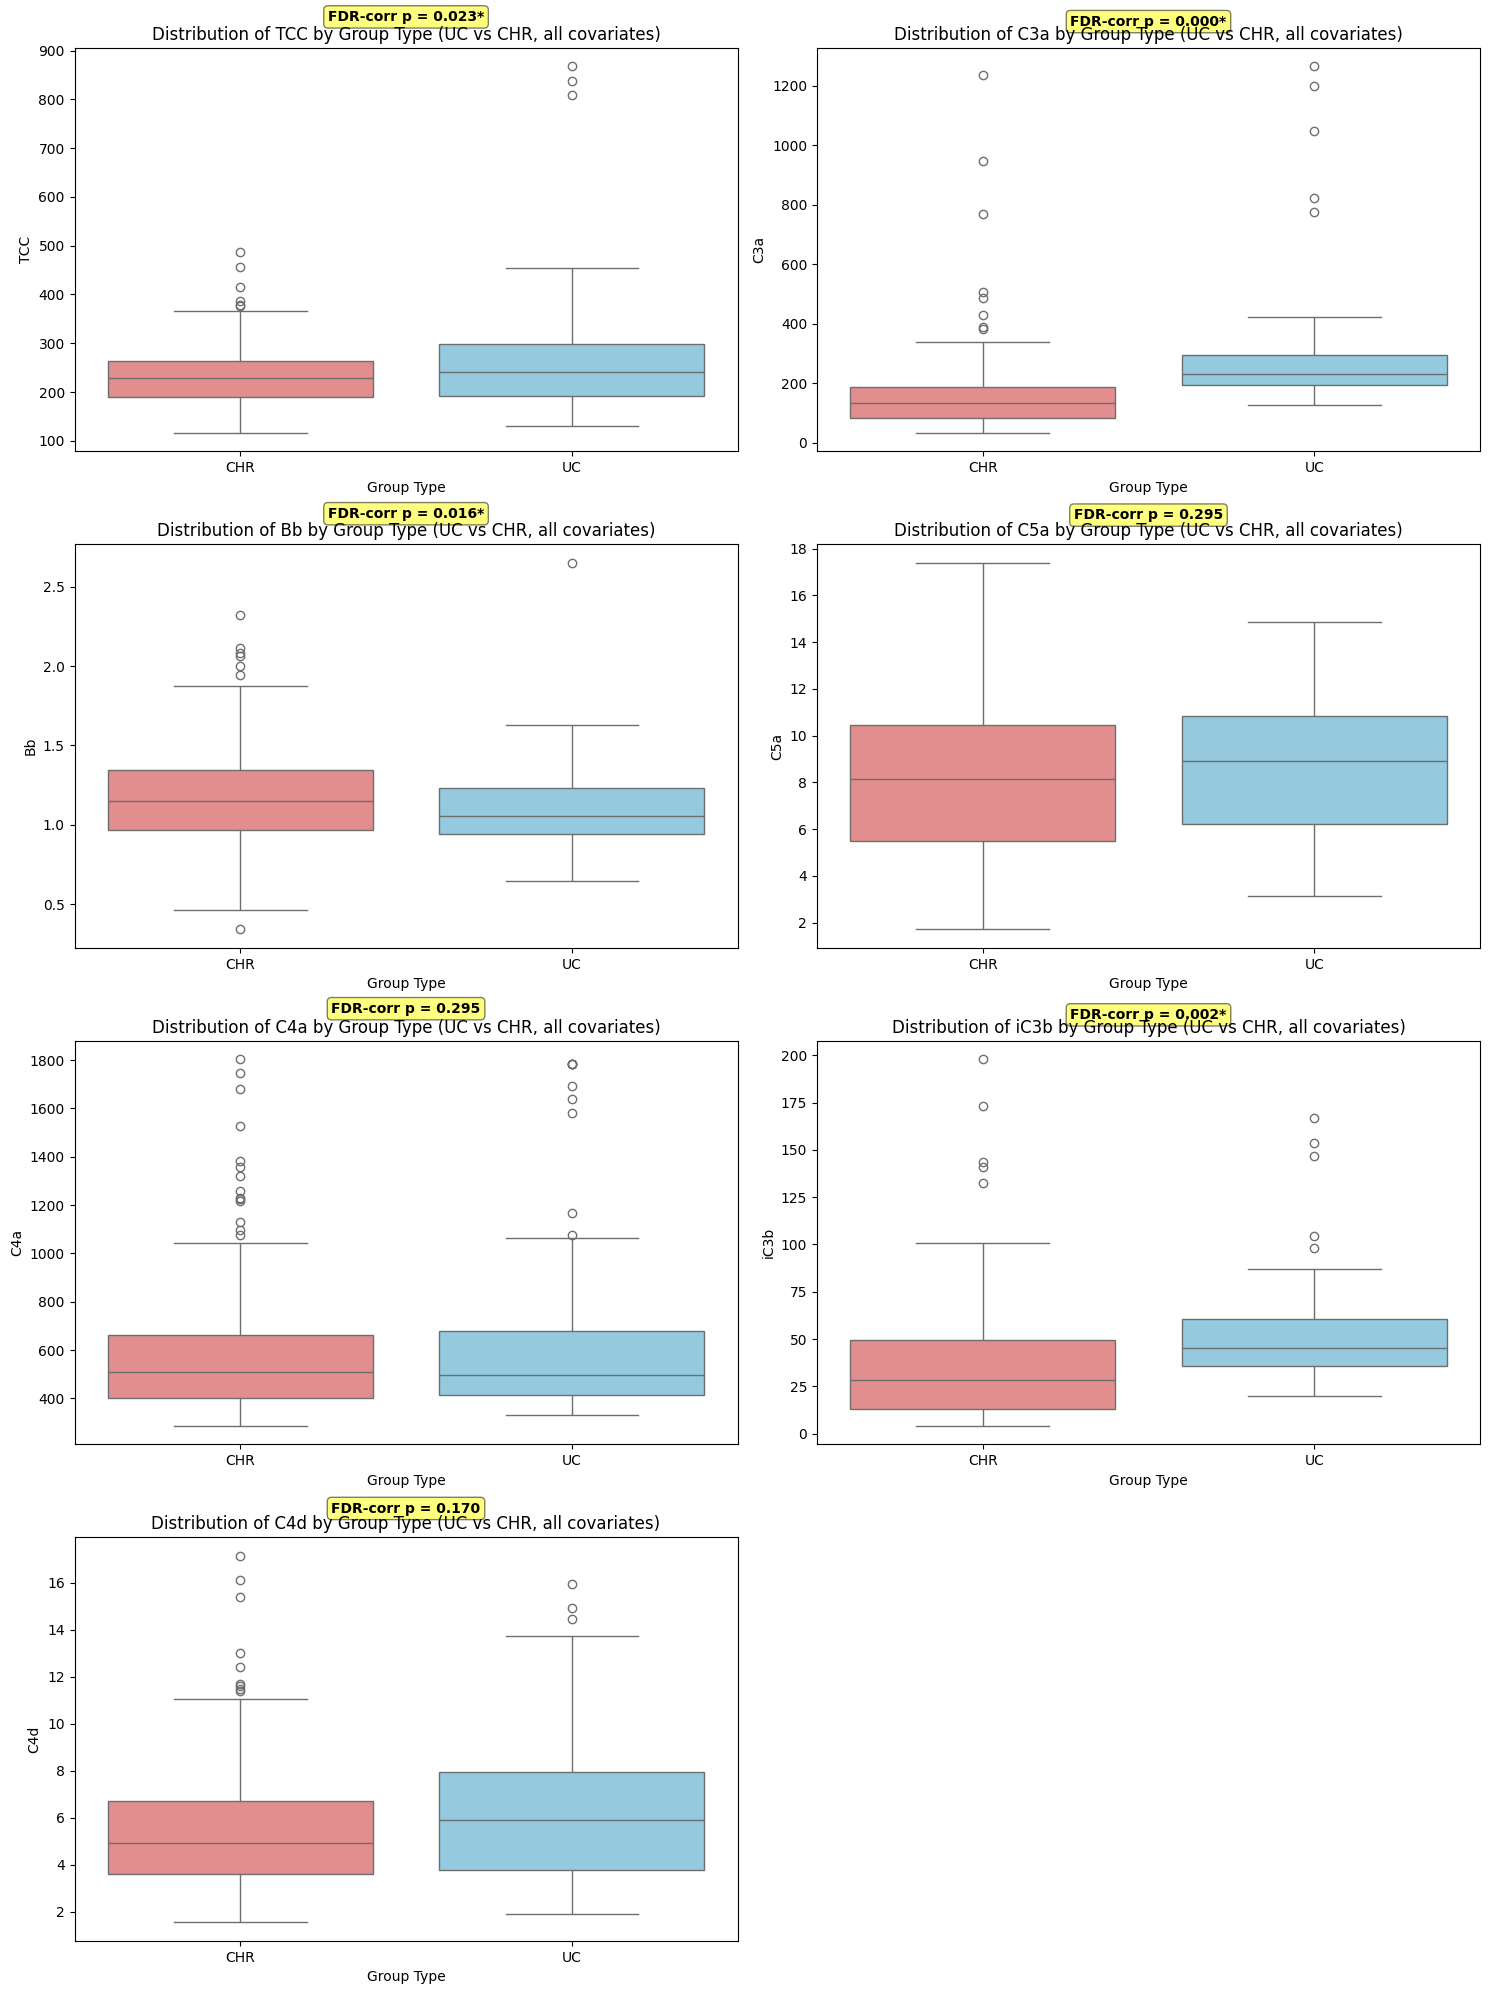

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define the columns for visualization
columns_to_visualize = ['TCC', 'C3a', 'Bb', 'C5a', 'C4a', 'iC3b', 'C4d']

print("Generating box plots comparing 'UC' vs 'CHR' groups (annotated with FDR-corrected ANCOVA p-values, accounting for all covariates)...")

# Create a dictionary for FDR-corrected p-values for UC vs CHR with all covariates
p_corrected_dict_uc_chr_all_cov = dict(zip(columns_for_fdr_uc_chr_all_cov, p_corrected_uc_chr_all_cov))

# Calculate number of rows and columns for subplots
num_cols = 2
num_rows = (len(columns_to_visualize) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columns_to_visualize):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='TYPE', y=col, data=df, hue='TYPE', palette={'UC': 'skyblue', 'CHR': 'lightcoral'}, legend=False)
    plt.title(f'Distribution of {col} by Group Type (UC vs CHR, all covariates)')
    plt.xlabel('Group Type')
    plt.ylabel(col)

    # Annotate with FDR-corrected ANCOVA p-value
    if col in p_corrected_dict_uc_chr_all_cov:
        p_value_fdr = p_corrected_dict_uc_chr_all_cov[col]

        # Get max_val for current column, handling potential empty data after filtering
        if not df[col].dropna().empty:
            max_val = df[col].max() * 1.1
        else:
            max_val = 1.0 # Default if no data

        p_value_text = f"FDR-corr p = {p_value_fdr:.3f}"

        if p_value_fdr < 0.05:
            p_value_text += "*"

        plt.text(0.5, max_val, p_value_text, ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))
    else:
        # Handle cases where ANCOVA could not be performed (e.g., insufficient data, no variability)
        if not df[col].dropna().empty:
            max_val = df[col].max() * 1.1
        else:
            max_val = 1.0
        plt.text(0.5, max_val, "ANCOVA not feasible", ha='center', va='bottom', fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()